In [ ]:
# Install required packages
%pip install --upgrade --quiet natural_pdf

print('✓ Packages installed!')

In [1]:
from natural_pdf import PDF
from pathlib import Path

pdf_path = Path.home() / "Documents/슬기중요문서/2025 graduate submission/Columbia/Class/DataStudio2026/first_project/농업면적표본.pdf"

pdf = PDF(str(pdf_path))
pdf

<PDF source='/Users/seulgijung/Documents/슬기중요문서/2025 graduate submission/Columbia/Class/DataStudio2026/first_project/농업면적표본.pdf' pages=74>

## Here i'm going to extract the tables that show a geographical trend in farming garlics, onions, cabbages, radish, and chilie pepper over the decade.

### 1. Garlic

In [2]:
# select the page in which the garlic table is embedded
g_page = pdf.pages[10]

g_page

<Page number=11 index=10>

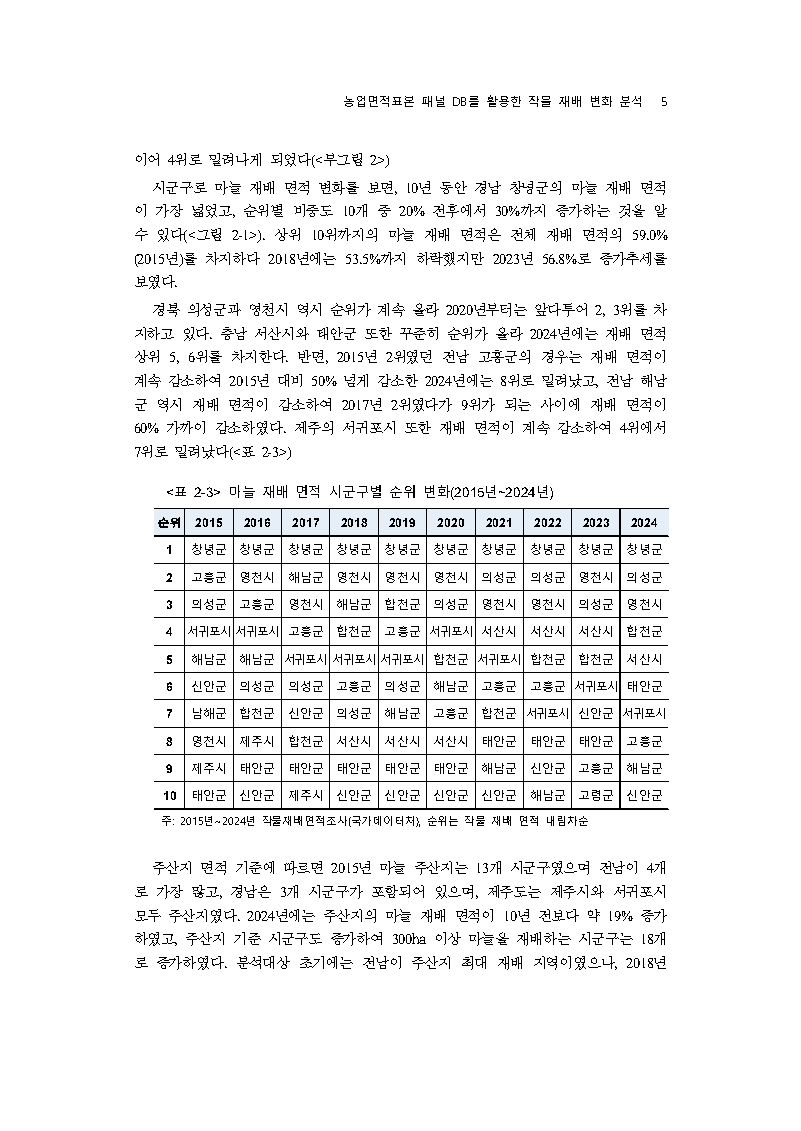

In [3]:
g_page.show(width=800)

In [4]:
# somehow .extract_table() fails to capture the last column so trying another way
g_table = g_page.extract_table()
g_table.to_df()

,순위,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,None,창녕군,창녕군,창녕군,창녕군,창녕군,창녕군,창녕군,창녕군,창녕군,None
1,None,고흥군,영천시,해남군,영천시,영천시,영천시,의성군,의성군,영천시,None
2,None,의성군,고흥군,영천시,해남군,합천군,의성군,영천시,영천시,의성군,None
3,None,서귀포시,서귀포시,고흥군,합천군,고흥군,서귀포시,서산시,서산시,서산시,None
4,None,해남군,해남군,서귀포시,서귀포시,서귀포시,합천군,서귀포시,합천군,합천군,None
5,None,신안군,의성군,의성군,고흥군,의성군,해남군,고흥군,고흥군,서귀포시,None
6,None,남해군,합천군,신안군,의성군,해남군,고흥군,합천군,서귀포시,신안군,None
7,None,영천시,제주시,합천군,서산시,서산시,서산시,태안군,태안군,태안군,None
8,None,제주시,태안군,태안군,태안군,태안군,태안군,해남군,신안군,고흥군,None
9,None,태안군,신안군,제주시,신안군,신안군,신안군,신안군,해남군,고령군,None


In [5]:
g_page.describe()

## Page 11 Summary

**Elements**:

- **text**: 265 elements
- **line**: 69 elements
- **rect**: 11 elements

**Text Analysis**:

- **typography**:
  - **fonts**:
    - MalgunGothic: 106
    - \xc8\xde\xb8\xd5\xb8\xed\xc1\xb6': 70
    - Times: 61
    - Arial: 26
    - GulimChe: 1
    - HCRBatang: 1
  - **sizes**:
    - 11.0pt: 132
    - 9.0pt: 122
    - 10.0pt: 10
    - 8.0pt: 1
  - styles: 20 bold, 4 underline

In [6]:
# use .inspect to find coordinate elements(x0, top, x1, bottom) that are used for .creat_region attribute to capture the table
# set the limit to 300 to see the coordinate number of firstcolumnfirstrow(1C1R) and lastcolumnlastrow(LCLR)
g_page.find_all('text').inspect(limit=300)

text,x0,top,x1,bottom,font_family,font_variant,size,styles,source,confidence,color
농업면적표본 패널 DB를 활용한 작물 재배 변화 분석 5,255,71,496,80,MalgunGothic,INPILL,9,,native,1.00,#000000
이어,99,113,125,124,\xc8\xde\xb8\xd5\xb8\xed\xc1\xb6',b'INPILL,11,,native,1.00,#000000
위로 밀려나게 되었다,130,113,231,124,\xc8\xde\xb8\xd5\xb8\xed\xc1\xb6',b'INPILL,11,,native,1.00,#000000
부그림,240,113,275,124,\xc8\xde\xb8\xd5\xb8\xed\xc1\xb6',b'INPILL,11,,native,1.00,#000000
4,125,114,130,125,Times,INPILL,11,,native,1.00,#000000
(<,231,114,240,125,Times,INPILL,11,,native,1.00,#000000
2>),275,114,289,125,Times,INPILL,11,,native,1.00,#000000
시군구로 마늘 재배 면적 변화를 보면,113,134,293,145,\xc8\xde\xb8\xd5\xb8\xed\xc1\xb6',b'INPILL,11,,native,1.00,#000000
년 동안 경남 창녕군의 마늘 재배 면적,311,134,496,145,\xc8\xde\xb8\xd5\xb8\xed\xc1\xb6',b'INPILL,11,,native,1.00,#000000
",",293,135,298,146,Times,INPILL,11,,native,1.00,#000000


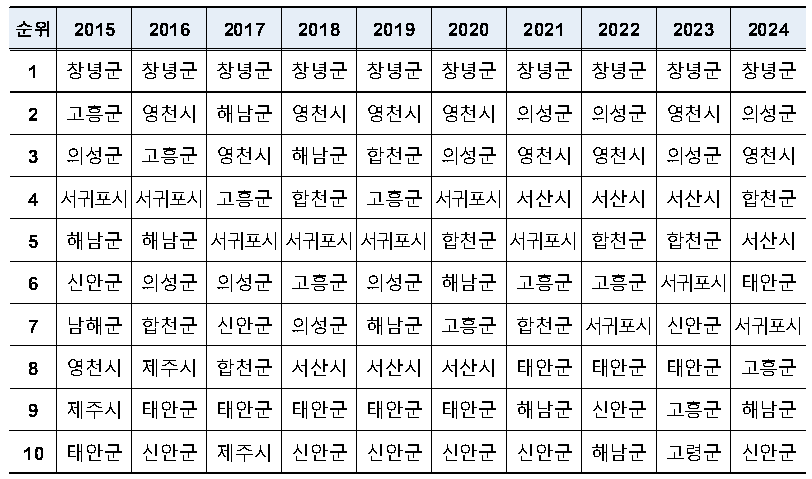

In [7]:

# select the table using the x0, top, x1, bottom elements 
# 1C1R = 117, 384, 135, 393; LCLR = 465, 588, 492, 597
# for left(x0) and top: 117, 384 smallest numbers of 1C1R ; for right(x1) and bottom: 492, 597 biggest numbers of lastClastR
# the first two numbers are a tad bigger while the rest are calibrated a tad larger than actual number 
# to give it some rooom and capture it right
g_table_region = g_page.create_region(
    x0=110,
    top=375,
    x1=500,
    bottom=605
)

g_table_region.show(crop=True)


In [8]:
# extract texts from the selected table
# another problem: the word "서귀포시" clustters with each other in line 4 and 5
g_text = g_table_region.extract_text()
g_text

'순위 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024\n1 창녕군 창녕군 창녕군 창녕군 창녕군 창녕군 창녕군 창녕군 창녕군 창녕군\n2 고흥군 영천시 해남군 영천시 영천시 영천시 의성군 의성군 영천시 의성군\n3 의성군 고흥군 영천시 해남군 합천군 의성군 영천시 영천시 의성군 영천시\n4 서귀포시서귀포시 고흥군 합천군 고흥군 서귀포시 서산시 서산시 서산시 합천군\n5 해남군 해남군 서귀포시서귀포시서귀포시 합천군 서귀포시 합천군 합천군 서산시\n6 신안군 의성군 의성군 고흥군 의성군 해남군 고흥군 고흥군 서귀포시 태안군\n7 남해군 합천군 신안군 의성군 해남군 고흥군 합천군 서귀포시 신안군 서귀포시\n8 영천시 제주시 합천군 서산시 서산시 서산시 태안군 태안군 태안군 고흥군\n9 제주시 태안군 태안군 태안군 태안군 태안군 해남군 신안군 고흥군 해남군\n10 태안군 신안군 제주시 신안군 신안군 신안군 신안군 해남군 고령군 신안군'

In [9]:
# formulate a function that can dissolve the clutters
# disclosure: AI is used actively for this part

import re

def split_korean_regions(line):
    parts = line.split(maxsplit=1) # split by blank space but do so only once so that the first element, which is a number, is removed and the rest can be regexed. save em as `parts`
    rank = parts[0] # the first element of `parts`, the number split off line, is the ranking so store it as `rank`
    rest = parts[1] if len(parts) > 1 else "" # if there's the second element, which there should, store it as `rest`. leave it as blank in case `parts` went wrong and and has no second element.
    
    # use non-greedy so it can stop at the encounter of "군" or "시"
    regions = re.findall(r'[가-힣]+?(?:군|시)', rest)
    
    return [rank] + regions 


# test
for i in [4, 5]:
    print(i, split_korean_regions(g_lines[i]))


NameError: name 'g_lines' is not defined

#### **regex explanation**


`r'[가-힣]+?(?:군|시)', rest`

1. `re.findall(...)` : find all strings from `rest` that match the pattern and return them in list
2. `r''` : raw string. refrain python from interpreting a backslash escape like `\n`. this is a usual practice when using regex.
3. `[가-힣]` : one korean syllable. e.g., ‘서’, ‘귀’, ‘포’, ‘시’, ‘태’, ‘안’, ‘군'
- `[...]` : range to choose one letter from
- `가-힣` : range of korean syllable; 
4. `+?` : 
- `+` : means repeat the pattern that comes right before => `[가-힣]+` means more than one korean syllable follows; e.g., "서귀포시서귀포시" fits here too.
- `?` : followed by `?`, `+?` means find the least extended match, (= non-greedy/lazy)
- that is to say, find one Korean syllable first and stop later at the point that meets that condition

given "서귀포시서귀포시"

A. if it was `[가-힣]+` (greedy), regex captures the "서귀포시서귀포시" wholesale, with no split because "서귀포시서귀포시" ends with '시'

B. if it was `[가-힣]+?` (non-greedy/lazy), regext first captures it brief and sees if the follwoing condition is met.
the following condition is `(?:군|시)` so it stops upon either letter appears.

5. `(?:군|시)` : the condition dictates that it end with "군" or "시"
- `(...)` : a group
- `군|시` : "군" or "시"
- `(?: ... )` : a group that won't be captured; `(...)` can ...? when combined with a function like findall, so `?:` is added here to indicate. 


**요약설명**

- [가-힣]+? : 한글을 최소 매칭
- (?:군|시) : 그 뒤가 ‘군’ 또는 ‘시’로 끝나는 지점까지를 하나의 덩어리로 매칭합니다.

실제로 "서귀포시서귀포시"에서 어떻게 작동하는지 단계로 보면:

- 가능한 가장 짧게 [가-힣]+?를 잡기 시작: ‘서’
- 뒤에 바로 ‘군/시’가 오나? 아니오(뒤는 ‘귀’)
- 조금 더 늘림: ‘서귀’
- 뒤에 ‘군/시’가 오나? 아니오
- … 반복 …
- ‘서귀포’까지 늘림 → '시'로 끝나나? 아니오
- 결국 한글자 더 잡아서 '서귀포시' 형태가 되는 순간, (?:군|시) 조건을 만족.

그래서 첫 매칭이 서귀포시로 끝납니다. findall은 그 다음 위치에서 다시 같은 패턴을 찾아서 두 번째 서귀포시도 잡습니다.

In [10]:
# split g_text by row (\n is line break <br>) first, creating an environment where the function can be applied
# which means that g_text shouldl be split into each row that starts with number (number will be stored in rank by the function)
# each element in the list = each row

g_lines = g_text.strip().split("\n")
g_lines

['순위 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024',
 '1 창녕군 창녕군 창녕군 창녕군 창녕군 창녕군 창녕군 창녕군 창녕군 창녕군',
 '2 고흥군 영천시 해남군 영천시 영천시 영천시 의성군 의성군 영천시 의성군',
 '3 의성군 고흥군 영천시 해남군 합천군 의성군 영천시 영천시 의성군 영천시',
 '4 서귀포시서귀포시 고흥군 합천군 고흥군 서귀포시 서산시 서산시 서산시 합천군',
 '5 해남군 해남군 서귀포시서귀포시서귀포시 합천군 서귀포시 합천군 합천군 서산시',
 '6 신안군 의성군 의성군 고흥군 의성군 해남군 고흥군 고흥군 서귀포시 태안군',
 '7 남해군 합천군 신안군 의성군 해남군 고흥군 합천군 서귀포시 신안군 서귀포시',
 '8 영천시 제주시 합천군 서산시 서산시 서산시 태안군 태안군 태안군 고흥군',
 '9 제주시 태안군 태안군 태안군 태안군 태안군 해남군 신안군 고흥군 해남군',
 '10 태안군 신안군 제주시 신안군 신안군 신안군 신안군 해남군 고령군 신안군']

In [11]:
# then apply the function to each row

g_rows = [split_korean_regions(line) for line in g_lines[1:]]
g_rows

[['1', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군'],
 ['2', '고흥군', '영천시', '해남군', '영천시', '영천시', '영천시', '의성군', '의성군', '영천시', '의성군'],
 ['3', '의성군', '고흥군', '영천시', '해남군', '합천군', '의성군', '영천시', '영천시', '의성군', '영천시'],
 ['4',
  '서귀포시',
  '서귀포시',
  '고흥군',
  '합천군',
  '고흥군',
  '서귀포시',
  '서산시',
  '서산시',
  '서산시',
  '합천군'],
 ['5',
  '해남군',
  '해남군',
  '서귀포시',
  '서귀포시',
  '서귀포시',
  '합천군',
  '서귀포시',
  '합천군',
  '합천군',
  '서산시'],
 ['6', '신안군', '의성군', '의성군', '고흥군', '의성군', '해남군', '고흥군', '고흥군', '서귀포시', '태안군'],
 ['7', '남해군', '합천군', '신안군', '의성군', '해남군', '고흥군', '합천군', '서귀포시', '신안군', '서귀포시'],
 ['8', '영천시', '제주시', '합천군', '서산시', '서산시', '서산시', '태안군', '태안군', '태안군', '고흥군'],
 ['9', '제주시', '태안군', '태안군', '태안군', '태안군', '태안군', '해남군', '신안군', '고흥군', '해남군'],
 ['10', '태안군', '신안군', '제주시', '신안군', '신안군', '신안군', '신안군', '해남군', '고령군', '신안군']]

In [22]:
korean_province = {
'가평군': 'Gapyeong-gun',
'강남구': 'Gangnam-gu',
'강동구': 'Gangdong-gu',
'강릉시': 'Gangneung-si',
'강북구': 'Gangbuk-gu',
'강서구, 부산광역시': 'Gangseo-gu, Busan',
'강서구, 서울특별시': 'Gangseo-gu, Seoul',
'강진군': 'Gangjin-gun',
'강화군': 'Ganghwa-gun',
'거제시': 'Geoje-si',
'거창군': 'Geochang-gun',
'경산시': 'Gyeongsan-si',
'경주시': 'Gyeongju-si',
'계룡시': 'Gyeryong-si',
'계양구': 'Gyeyang-gu',
'고령군': 'Goryeong-gun',
'고성군, 강원특별자치도': 'Goseong-gun, Gangwon State',
'고성군, 경상남도': 'Goseong-gun, South Gyeongsang',
'고양시': 'Goyang-si',
'고창군': 'Gochang-gun',
'고흥군': 'Goheung-gun',
'곡성군': 'Gokseong-gun',
'공주시': 'Gongju-si',
'과천시': 'Gwacheon-si',
'관악구': 'Gwanak-gu',
'광명시': 'Gwangmyeong',
'광산구': 'Gwangsan-gu',
'광양시': 'Gwangyang-si',
'광주시': 'Gwangju-si',
'광진구': 'Gwangjin-gu',
'괴산군': 'Goesan-gun',
'구례군': 'Gurye-gun',
'구로구': 'Guro-gu',
'구리시': 'Guri-si',
'구미시': 'Gumi-si',
'군산시': 'Gunsan-si',
'군위군': 'Gunwi-gun',
'군포시': 'Gunpo-si',
'금산군': 'Geumsan-gun',
'금정구': 'Geumjeong-gu',
'금천구': 'Geumcheon-gu',
'기장군': 'Gijang-gun',
'김제시': 'Gimje-si',
'김천시': 'Gimcheon-si',
'김포시': 'Gimpo-si',
'김해시': 'Gimhae-si',
'나주시': 'Naju-si',
'남구, 광주광역시': 'Nam-gu, Gwangju',
'남구, 대구광역시': 'Nam-gu, Daegu',
'남구, 부산광역시': 'Nam-gu, Busan',
'남구, 울산광역시': 'Nam-gu, Ulsan',
'남동구': 'Namdong-gu',
'남양주시': 'Namyangju-si',
'남원시': 'Namwon-si',
'남해군': 'Namhae-gun',
'노원구': 'Nowon-gu',
'논산시': 'Nonsan-si',
'단양군': 'Danyang-gun',
'달서구': 'Dalseo-gu',
'달성군': 'Dalseong-gun',
'담양군': 'Damyang-gun',
'당진시': 'Dangjin-si',
'대덕구': 'Daedeok-gu',
'도봉구': 'Dobong-gu',
'동구, 광주광역시': 'Dong-gu, Gwangju',
'동구, 대구광역시': 'Dong-gu, Daegu',
'동구, 대전광역시': 'Dong-gu, Daejeon',
'동구, 부산광역시': 'Dong-gu, Busan',
'동구, 울산광역시': 'Dong-gu, Ulsan',
'동구, 인천광역시': 'Dong-gu, Incheon',
'동대문구': 'Dongdaemun-gu',
'동두천시': 'Dongducheon-si',
'동래구': 'Dongnae-gu',
'동작구': 'Dongjak-gu',
'동해시': 'Donghae-si',
'마포구': 'Mapo-gu',
'목포시': 'Mokpo-si',
'무안군': 'Muan-gun',
'무주군': 'Muju-gun',
'문경시': 'Mungyeong-si',
'미추홀구': 'Michuhol-gu',
'밀양시': 'Miryang-si',
'보령시': 'Boryeong-si',
'보성군': 'Boseong-gun',
'보은군': 'Boeun-gun',
'봉화군': 'Bonghwa-gun',
'부산진구': 'Busanjin-gu',
'부안군': 'Buan-gun',
'부여군': 'Buyeo-gun',
'부천시': 'Bucheon-si',
'부평구': 'Bupyeong-gu',
'북구, 광주광역시': 'Buk-gu, Gwangju',
'북구, 대구광역시': 'Buk-gu, Daegu',
'북구, 부산광역시': 'Buk-gu, Busan',
'북구, 울산광역시': 'Buk-gu, Ulsan',
'사상구': 'Sasang-gu',
'사천시': 'Sacheon-si',
'사하구': 'Saha-gu',
'산청군': 'Sancheong-gun',
'삼척시': 'Samcheok-si',
'상주시': 'Sangju-si',
'서구, 광주광역시': 'Seo-gu, Gwangju',
'서구, 대구광역시': 'Seo-gu, Daegu',
'서구, 대전광역시': 'Seo-gu, Daejeon',
'서구, 부산광역시': 'Seo-gu, Busan',
'서구, 인천광역시': 'Seo-gu, Incheon',
'서귀포시': 'Seogwipo-si',
'서대문구': 'Seodaemun-gu',
'서산시': 'Seosan-si',
'서천군': 'Seocheon-gun',
'서초구': 'Seocho-gu',
'성남시': 'Seongnam-si',
'성동구': 'Seongdong-gu',
'성북구': 'Seongbuk-gu',
'성주군': 'Seongju-gun',
'세종특별자치시': 'Sejong',
'속초시': 'Sokcho-si',
'송파구': 'Songpa-gu',
'수성구': 'Suseong-gu',
'수영구': 'Suyeong-gu',
'수원시': 'Suwon-si',
'순창군': 'Sunchang-gun',
'순천시': 'Suncheon-si',
'시흥시': 'Siheung-si',
'신안군': 'Sinan-gun',
'아산시': 'Asan-si',
'안동시': 'Andong-si',
'안산시': 'Ansan',
'안성시': 'Anseong-si',
'안양시': 'Anyang-si',
'양구군': 'Yanggu-gun',
'양산시': 'Yangsan-si',
'양양군': 'Yangyang-gun',
'양주시': 'Yangju',
'양천구': 'Yangcheon-gu',
'양평군': 'Yangpyeong-gun',
'여수시': 'Yeosu-si',
'여주시': 'Yeoju-si',
'연수구': 'Yeonsu-gu',
'연제구': 'Yeonje-gu',
'연천군': 'Yeoncheon-gun',
'영광군': 'Yeonggwang-gun',
'영덕군': 'Yeongdeok-gun',
'영동군': 'Yeongdong-gun',
'영등포구': 'Yeongdeungpo-gu',
'영암군': 'Yeongam-gun',
'영양군': 'Yeongyang-gun',
'영월군': 'Yeongwol-gun',
'영주시': 'Yeongju-si',
'영천시': 'Yeongcheon-si',
'예산군': 'Yesan-gun',
'예천군': 'Yecheon-gun',
'오산시': 'Osan-si',
'옥천군': 'Okcheon-gun',
'완도군': 'Wando-gun',
'완주군': 'Wanju-gun',
'용산구': 'Yongsan-gu',
'용인시': 'Yongin-si',
'울릉군': 'Ulleung-gun',
'울주군': 'Ulju-gun',
'울진군': 'Uljin-gun',
'원주시': 'Wonju-si',
'유성구': 'Yuseong-gu',
'은평구': 'Eunpyeong-gu',
'음성군': 'Eumseong-gun',
'의령군': 'Uiryeong-gun',
'의성군': 'Uiseong-gun',
'의왕시': 'Uiwang-si',
'의정부시': 'Uijeongbu-si',
'이천시': 'Icheon-si',
'익산시': 'Iksan-si',
'인제군': 'Inje-gun',
'임실군': 'Imsil-gun',
'장성군': 'Jangseong-gun',
'장수군': 'Jangsu-gun',
'장흥군': 'Jangheung-gun',
'전주시': 'Jeonju-si',
'정선군': 'Jeongseon-gun',
'정읍시': 'Jeongeup-si',
'제주시': 'Jeju-si',
'제천시': 'Jecheon-si',
'종로구': 'Jongno-gu',
'중구, 대구광역시': 'Jung-gu, Daegu',
'중구, 대전광역시': 'Jung-gu, Daejeon',
'중구, 부산광역시': 'Jung-gu, Busan',
'중구, 서울특별시': 'Jung-gu, Seoul',
'중구, 울산광역시': 'Jung-gu, Ulsan',
'중구, 인천광역시': 'Jung-gu, Incheon',
'중랑구': 'Jungnang-gu',
'증평군': 'Jeungpyeong-gun',
'진도군': 'Jindo-gun',
'진안군': 'Jinan-gun',
'진주시': 'Jinju-si',
'진천군': 'Jincheon-gun',
'창녕군': 'Changnyeong-gun',
'창원시': 'Changwon-si',
'천안시': 'Cheonan-si',
'철원군': 'Cheorwon-gun',
'청도군': 'Cheongdo-gun',
'청송군': 'Cheongsong-gun',
'청양군': 'Cheongyang-gun',
'청주시': 'Cheongju-si',
'춘천시': 'Chuncheon-si',
'충주시': 'Chungju-si',
'칠곡군': 'Chilgok-gun',
'태백시': 'Taebaek-si',
'태안군': 'Taean-gun',
'통영시': 'Tongyeong-si',
'파주시': 'Paju-si',
'평창군': 'Pyeongchang-gun',
'평택시': 'Pyeongtaek-si',
'포천시': 'Pocheon-si',
'포항시': 'Pohang-si',
'하남시': 'Hanam-si',
'하동군': 'Hadong-gun',
'함안군': 'Haman-gun',
'함양군': 'Hamyang-gun',
'함평군': 'Hampyeong-gun',
'합천군': 'Hapcheon-gun',
'해남군': 'Haenam-gun',
'해운대구': 'Haeundae-gu',
'홍성군': 'Hongseong-gun',
'홍천군': 'Hongcheon-gun',
'화성시': 'Hwaseong-si',
'화순군': 'Hwasun-gun',
'화천군': 'Hwacheon-gun',
'횡성군': 'Hoengseong-gun'
}


In [23]:
g_rows

[['1', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군'],
 ['2', '고흥군', '영천시', '해남군', '영천시', '영천시', '영천시', '의성군', '의성군', '영천시', '의성군'],
 ['3', '의성군', '고흥군', '영천시', '해남군', '합천군', '의성군', '영천시', '영천시', '의성군', '영천시'],
 ['4',
  '서귀포시',
  '서귀포시',
  '고흥군',
  '합천군',
  '고흥군',
  '서귀포시',
  '서산시',
  '서산시',
  '서산시',
  '합천군'],
 ['5',
  '해남군',
  '해남군',
  '서귀포시',
  '서귀포시',
  '서귀포시',
  '합천군',
  '서귀포시',
  '합천군',
  '합천군',
  '서산시'],
 ['6', '신안군', '의성군', '의성군', '고흥군', '의성군', '해남군', '고흥군', '고흥군', '서귀포시', '태안군'],
 ['7', '남해군', '합천군', '신안군', '의성군', '해남군', '고흥군', '합천군', '서귀포시', '신안군', '서귀포시'],
 ['8', '영천시', '제주시', '합천군', '서산시', '서산시', '서산시', '태안군', '태안군', '태안군', '고흥군'],
 ['9', '제주시', '태안군', '태안군', '태안군', '태안군', '태안군', '해남군', '신안군', '고흥군', '해남군'],
 ['10', '태안군', '신안군', '제주시', '신안군', '신안군', '신안군', '신안군', '해남군', '고령군', '신안군']]

In [25]:
# translate Korean into English

eng_g_rows = [
    [row[0]] + [korean_province.get(place, place) for place in row[1:]]
    for row in g_rows
]

eng_g_rows

[['1',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun'],
 ['2',
  'Goheung-gun',
  'Yeongcheon-si',
  'Haenam-gun',
  'Yeongcheon-si',
  'Yeongcheon-si',
  'Yeongcheon-si',
  'Uiseong-gun',
  'Uiseong-gun',
  'Yeongcheon-si',
  'Uiseong-gun'],
 ['3',
  'Uiseong-gun',
  'Goheung-gun',
  'Yeongcheon-si',
  'Haenam-gun',
  'Hapcheon-gun',
  'Uiseong-gun',
  'Yeongcheon-si',
  'Yeongcheon-si',
  'Uiseong-gun',
  'Yeongcheon-si'],
 ['4',
  'Seogwipo-si',
  'Seogwipo-si',
  'Goheung-gun',
  'Hapcheon-gun',
  'Goheung-gun',
  'Seogwipo-si',
  'Seosan-si',
  'Seosan-si',
  'Seosan-si',
  'Hapcheon-gun'],
 ['5',
  'Haenam-gun',
  'Haenam-gun',
  'Seogwipo-si',
  'Seogwipo-si',
  'Seogwipo-si',
  'Hapcheon-gun',
  'Seogwipo-si',
  'Hapcheon-gun',
  'Hapcheon-gun',
  'Seosan-si'],
 ['6',
  'Sinan-gun',
  'Uiseong-gun',
  'Uiseong-gun',
  

```python
english_rows = [
    [row[0]] + [korean_province.get(place, place) for place in row[1:]]
    for row in g_rows
]
```


1. `[` … `]` : list comprehension
* addressing each row out of `g_rows`, make a new list with translated rows.

2. `[row[0]] + ...`
* `row[0]` is the first element of each row, which is number
* `[row[0]]` : Turn it into a list by wrapping in a pair of square brackets, because in this way it can be consolidated with following list.
* That is to say, it anchors the first element number to its position.

3. `[korean_province.get(place, place) for place in row[1:]]` :  another list comprehension
* `row[1:]` ranges from the second element to the last, excluding the first element
* `for place in row[1:]` : retreiving Korean province names one by one
* `korean_province.get(place, place)` : `korean_province` is a Ko-En mapping dictionary
* `.get(place, place)` means if it has a matching key, the english value is returned accordingly. If not, give it a default value. here, the default value is set to `place`, so Korean name remains unless there's no mapping. (to avert error)
*  `.get(key, default_value)` is a safe way to find a matching key, designed to avert a zero-key-matching error. 

4. in a nut shell, each row:
  * the first element sustains `[row[0]]`
  * the rest will be assigned an english name
  * these two are amalgamated using `+` plus sign
  * all these actions form a new variabl `english_rows`

for example, 

* input: `['6', '신안군', '의성군']`
* transformation:
  * `[row[0]]` → `['6']`
  * the rest→ `['Sinan-gun', 'Uiseong-gun']`
  * congregation → `['6', 'Sinan-gun', 'Uiseong-gun']`



In [26]:
# pull the header from rows, split it into each cell value, and then save
g_header = g_lines[0].split()
g_header

['순위',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024']

In [27]:
# consolidate g_rows and g_header into g_df

import pandas as pd

g_df = pd.DataFrame(eng_g_rows, columns=g_header)
g_df.head(10)

,순위,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun
1,2,Goheung-gun,Yeongcheon-si,Haenam-gun,Yeongcheon-si,Yeongcheon-si,Yeongcheon-si,Uiseong-gun,Uiseong-gun,Yeongcheon-si,Uiseong-gun
2,3,Uiseong-gun,Goheung-gun,Yeongcheon-si,Haenam-gun,Hapcheon-gun,Uiseong-gun,Yeongcheon-si,Yeongcheon-si,Uiseong-gun,Yeongcheon-si
3,4,Seogwipo-si,Seogwipo-si,Goheung-gun,Hapcheon-gun,Goheung-gun,Seogwipo-si,Seosan-si,Seosan-si,Seosan-si,Hapcheon-gun
4,5,Haenam-gun,Haenam-gun,Seogwipo-si,Seogwipo-si,Seogwipo-si,Hapcheon-gun,Seogwipo-si,Hapcheon-gun,Hapcheon-gun,Seosan-si
5,6,Sinan-gun,Uiseong-gun,Uiseong-gun,Goheung-gun,Uiseong-gun,Haenam-gun,Goheung-gun,Goheung-gun,Seogwipo-si,Taean-gun
6,7,Namhae-gun,Hapcheon-gun,Sinan-gun,Uiseong-gun,Haenam-gun,Goheung-gun,Hapcheon-gun,Seogwipo-si,Sinan-gun,Seogwipo-si
7,8,Yeongcheon-si,Jeju-si,Hapcheon-gun,Seosan-si,Seosan-si,Seosan-si,Taean-gun,Taean-gun,Taean-gun,Goheung-gun
8,9,Jeju-si,Taean-gun,Taean-gun,Taean-gun,Taean-gun,Taean-gun,Haenam-gun,Sinan-gun,Goheung-gun,Haenam-gun
9,10,Taean-gun,Sinan-gun,Jeju-si,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Haenam-gun,Goryeong-gun,Sinan-gun


In [28]:
# reverse the ranking: change ranking to score by which number one gets the most point (10) as number ten gets the least point (1)

g_df = g_df.drop(columns='순위')
g_df['score'] = [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
g_df

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,score
0,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,10
1,Goheung-gun,Yeongcheon-si,Haenam-gun,Yeongcheon-si,Yeongcheon-si,Yeongcheon-si,Uiseong-gun,Uiseong-gun,Yeongcheon-si,Uiseong-gun,9
2,Uiseong-gun,Goheung-gun,Yeongcheon-si,Haenam-gun,Hapcheon-gun,Uiseong-gun,Yeongcheon-si,Yeongcheon-si,Uiseong-gun,Yeongcheon-si,8
3,Seogwipo-si,Seogwipo-si,Goheung-gun,Hapcheon-gun,Goheung-gun,Seogwipo-si,Seosan-si,Seosan-si,Seosan-si,Hapcheon-gun,7
4,Haenam-gun,Haenam-gun,Seogwipo-si,Seogwipo-si,Seogwipo-si,Hapcheon-gun,Seogwipo-si,Hapcheon-gun,Hapcheon-gun,Seosan-si,6
5,Sinan-gun,Uiseong-gun,Uiseong-gun,Goheung-gun,Uiseong-gun,Haenam-gun,Goheung-gun,Goheung-gun,Seogwipo-si,Taean-gun,5
6,Namhae-gun,Hapcheon-gun,Sinan-gun,Uiseong-gun,Haenam-gun,Goheung-gun,Hapcheon-gun,Seogwipo-si,Sinan-gun,Seogwipo-si,4
7,Yeongcheon-si,Jeju-si,Hapcheon-gun,Seosan-si,Seosan-si,Seosan-si,Taean-gun,Taean-gun,Taean-gun,Goheung-gun,3
8,Jeju-si,Taean-gun,Taean-gun,Taean-gun,Taean-gun,Taean-gun,Haenam-gun,Sinan-gun,Goheung-gun,Haenam-gun,2
9,Taean-gun,Sinan-gun,Jeju-si,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Haenam-gun,Goryeong-gun,Sinan-gun,1


In [29]:
# save it as csv file

g_df.to_csv("garlic.csv", index=False)

### 2. Onion

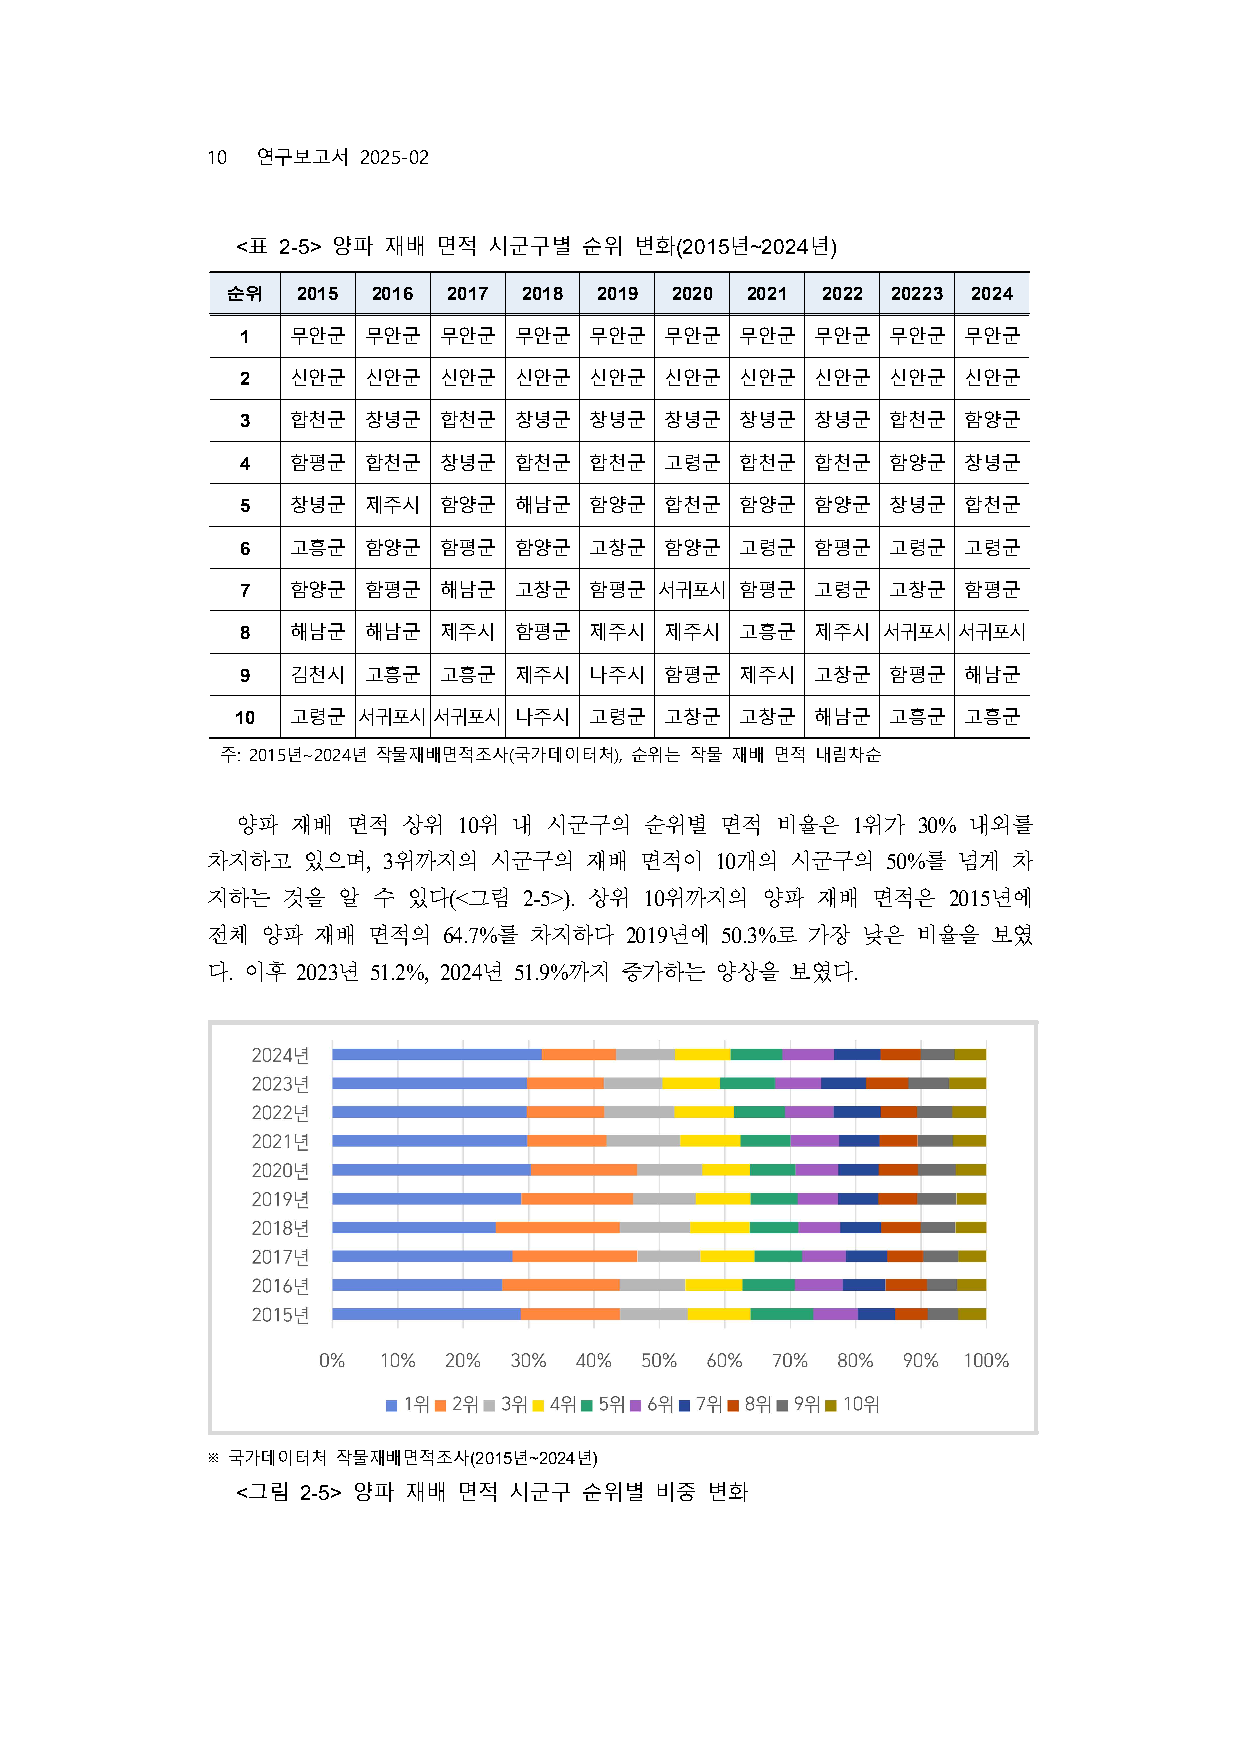

In [31]:
o_page = pdf.pages[15]
o_page.show()

In [32]:
o_page.find_all('text').inspect(limit=180)

text,x0,top,x1,bottom,font_family,font_variant,size,styles,source,confidence,color
10 연구보고서 2025-02,99,71,206,80,MalgunGothic,INPILL,9,,native,1.00,#000000
표,119,114,133,124,MalgunGothic,INPILL,10,,native,1.00,#000000
양파 재배 면적 시군구별 순위 변화,159,114,324,124,MalgunGothic,INPILL,10,,native,1.00,#000000
년,350,114,360,124,MalgunGothic,INPILL,10,,native,1.00,#000000
년,388,114,398,124,MalgunGothic,INPILL,10,,native,1.00,#000000
<,113,114,119,124,Arial,INPILL,10,,native,1.00,#000000
2-5>,134,114,157,124,Arial,INPILL,10,,native,1.00,#000000
(2015,324,114,350,124,Arial,INPILL,10,,native,1.00,#000000
~2024,360,114,388,124,Arial,INPILL,10,,native,1.00,#000000
),398,114,401,124,Arial,INPILL,10,,native,1.00,#000000


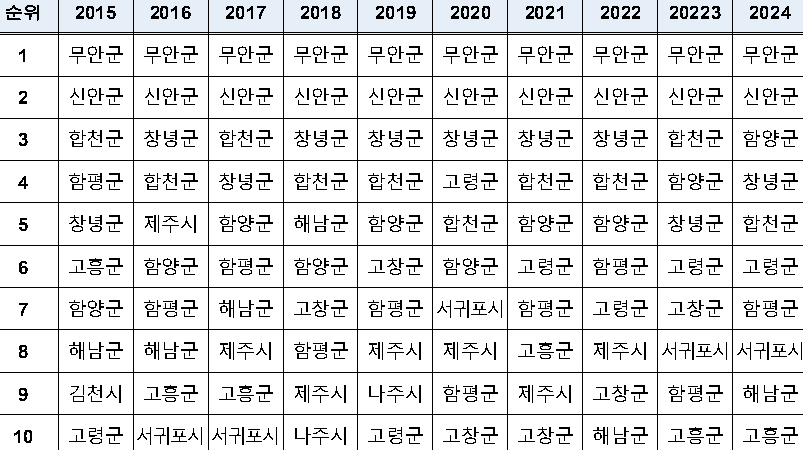

In [33]:
o_page.find_all('text').inspect(limit=200)

o_table_region = o_page.create_region(
    x0 = 107,
    top = 135,
    x1 = 492,
    bottom = 351
)

o_table_region.show(crop=True)

In [34]:
o_text = o_table_region.extract_text()
o_text

'순위 2015 2016 2017 2018 2019 2020 2021 2022 20223 2024\n1 무안군 무안군 무안군 무안군 무안군 무안군 무안군 무안군 무안군 무안군\n2 신안군 신안군 신안군 신안군 신안군 신안군 신안군 신안군 신안군 신안군\n3 합천군 창녕군 합천군 창녕군 창녕군 창녕군 창녕군 창녕군 합천군 함양군\n4 함평군 합천군 창녕군 합천군 합천군 고령군 합천군 합천군 함양군 창녕군\n5 창녕군 제주시 함양군 해남군 함양군 합천군 함양군 함양군 창녕군 합천군\n6 고흥군 함양군 함평군 함양군 고창군 함양군 고령군 함평군 고령군 고령군\n7 함양군 함평군 해남군 고창군 함평군 서귀포시 함평군 고령군 고창군 함평군\n8 해남군 해남군 제주시 함평군 제주시 제주시 고흥군 제주시 서귀포시서귀포시\n9 김천시 고흥군 고흥군 제주시 나주시 함평군 제주시 고창군 함평군 해남군\n10 고령군 서귀포시서귀포시 나주시 고령군 고창군 고창군 해남군 고흥군 고흥군'

In [35]:
o_lines = o_text.strip().split('\n')
o_lines

['순위 2015 2016 2017 2018 2019 2020 2021 2022 20223 2024',
 '1 무안군 무안군 무안군 무안군 무안군 무안군 무안군 무안군 무안군 무안군',
 '2 신안군 신안군 신안군 신안군 신안군 신안군 신안군 신안군 신안군 신안군',
 '3 합천군 창녕군 합천군 창녕군 창녕군 창녕군 창녕군 창녕군 합천군 함양군',
 '4 함평군 합천군 창녕군 합천군 합천군 고령군 합천군 합천군 함양군 창녕군',
 '5 창녕군 제주시 함양군 해남군 함양군 합천군 함양군 함양군 창녕군 합천군',
 '6 고흥군 함양군 함평군 함양군 고창군 함양군 고령군 함평군 고령군 고령군',
 '7 함양군 함평군 해남군 고창군 함평군 서귀포시 함평군 고령군 고창군 함평군',
 '8 해남군 해남군 제주시 함평군 제주시 제주시 고흥군 제주시 서귀포시서귀포시',
 '9 김천시 고흥군 고흥군 제주시 나주시 함평군 제주시 고창군 함평군 해남군',
 '10 고령군 서귀포시서귀포시 나주시 고령군 고창군 고창군 해남군 고흥군 고흥군']

In [36]:
o_rows = [split_korean_regions(o_line) for o_line in o_lines[1:]]
o_rows

[['1', '무안군', '무안군', '무안군', '무안군', '무안군', '무안군', '무안군', '무안군', '무안군', '무안군'],
 ['2', '신안군', '신안군', '신안군', '신안군', '신안군', '신안군', '신안군', '신안군', '신안군', '신안군'],
 ['3', '합천군', '창녕군', '합천군', '창녕군', '창녕군', '창녕군', '창녕군', '창녕군', '합천군', '함양군'],
 ['4', '함평군', '합천군', '창녕군', '합천군', '합천군', '고령군', '합천군', '합천군', '함양군', '창녕군'],
 ['5', '창녕군', '제주시', '함양군', '해남군', '함양군', '합천군', '함양군', '함양군', '창녕군', '합천군'],
 ['6', '고흥군', '함양군', '함평군', '함양군', '고창군', '함양군', '고령군', '함평군', '고령군', '고령군'],
 ['7', '함양군', '함평군', '해남군', '고창군', '함평군', '서귀포시', '함평군', '고령군', '고창군', '함평군'],
 ['8', '해남군', '해남군', '제주시', '함평군', '제주시', '제주시', '고흥군', '제주시', '서귀포시', '서귀포시'],
 ['9', '김천시', '고흥군', '고흥군', '제주시', '나주시', '함평군', '제주시', '고창군', '함평군', '해남군'],
 ['10',
  '고령군',
  '서귀포시',
  '서귀포시',
  '나주시',
  '고령군',
  '고창군',
  '고창군',
  '해남군',
  '고흥군',
  '고흥군']]

In [40]:
# translate Korean to English

eng_o_rows = [
    [o_row[0]] + [korean_province.get(place, place) for place in o_row[1:]]
    for o_row in o_rows
]

eng_o_rows

[['1',
  'Muan-gun',
  'Muan-gun',
  'Muan-gun',
  'Muan-gun',
  'Muan-gun',
  'Muan-gun',
  'Muan-gun',
  'Muan-gun',
  'Muan-gun',
  'Muan-gun'],
 ['2',
  'Sinan-gun',
  'Sinan-gun',
  'Sinan-gun',
  'Sinan-gun',
  'Sinan-gun',
  'Sinan-gun',
  'Sinan-gun',
  'Sinan-gun',
  'Sinan-gun',
  'Sinan-gun'],
 ['3',
  'Hapcheon-gun',
  'Changnyeong-gun',
  'Hapcheon-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Changnyeong-gun',
  'Hapcheon-gun',
  'Hamyang-gun'],
 ['4',
  'Hampyeong-gun',
  'Hapcheon-gun',
  'Changnyeong-gun',
  'Hapcheon-gun',
  'Hapcheon-gun',
  'Goryeong-gun',
  'Hapcheon-gun',
  'Hapcheon-gun',
  'Hamyang-gun',
  'Changnyeong-gun'],
 ['5',
  'Changnyeong-gun',
  'Jeju-si',
  'Hamyang-gun',
  'Haenam-gun',
  'Hamyang-gun',
  'Hapcheon-gun',
  'Hamyang-gun',
  'Hamyang-gun',
  'Changnyeong-gun',
  'Hapcheon-gun'],
 ['6',
  'Goheung-gun',
  'Hamyang-gun',
  'Hampyeong-gun',
  'Hamyang-gun',
  'Gochang-gun',
  'Hamyang-gun',
 

In [41]:
o_header = o_lines[0].split()
o_header

['순위',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '20223',
 '2024']

In [48]:
o_df = pd.DataFrame(eng_o_rows, columns=o_header)
o_df.head(10)

,순위,2015,2016,2017,2018,2019,2020,2021,2022,20223,2024
0,1,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun
1,2,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun
2,3,Hapcheon-gun,Changnyeong-gun,Hapcheon-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Hapcheon-gun,Hamyang-gun
3,4,Hampyeong-gun,Hapcheon-gun,Changnyeong-gun,Hapcheon-gun,Hapcheon-gun,Goryeong-gun,Hapcheon-gun,Hapcheon-gun,Hamyang-gun,Changnyeong-gun
4,5,Changnyeong-gun,Jeju-si,Hamyang-gun,Haenam-gun,Hamyang-gun,Hapcheon-gun,Hamyang-gun,Hamyang-gun,Changnyeong-gun,Hapcheon-gun
5,6,Goheung-gun,Hamyang-gun,Hampyeong-gun,Hamyang-gun,Gochang-gun,Hamyang-gun,Goryeong-gun,Hampyeong-gun,Goryeong-gun,Goryeong-gun
6,7,Hamyang-gun,Hampyeong-gun,Haenam-gun,Gochang-gun,Hampyeong-gun,Seogwipo-si,Hampyeong-gun,Goryeong-gun,Gochang-gun,Hampyeong-gun
7,8,Haenam-gun,Haenam-gun,Jeju-si,Hampyeong-gun,Jeju-si,Jeju-si,Goheung-gun,Jeju-si,Seogwipo-si,Seogwipo-si
8,9,Gimcheon-si,Goheung-gun,Goheung-gun,Jeju-si,Naju-si,Hampyeong-gun,Jeju-si,Gochang-gun,Hampyeong-gun,Haenam-gun
9,10,Goryeong-gun,Seogwipo-si,Seogwipo-si,Naju-si,Goryeong-gun,Gochang-gun,Gochang-gun,Haenam-gun,Goheung-gun,Goheung-gun


In [ ]:
o_df = o_df.drop(columns='순위')
o_df['score'] = [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
o_df = o_df.rename(columns={'20223':'2023'})
o_df.to_csv("onion.csv", index=False)

o_df.head()

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,score
0,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,Muan-gun,10
1,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,Sinan-gun,9
2,Hapcheon-gun,Changnyeong-gun,Hapcheon-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Changnyeong-gun,Hapcheon-gun,Hamyang-gun,8
3,Hampyeong-gun,Hapcheon-gun,Changnyeong-gun,Hapcheon-gun,Hapcheon-gun,Goryeong-gun,Hapcheon-gun,Hapcheon-gun,Hamyang-gun,Changnyeong-gun,7
4,Changnyeong-gun,Jeju-si,Hamyang-gun,Haenam-gun,Hamyang-gun,Hapcheon-gun,Hamyang-gun,Hamyang-gun,Changnyeong-gun,Hapcheon-gun,6


### 3. Autumn cabbage

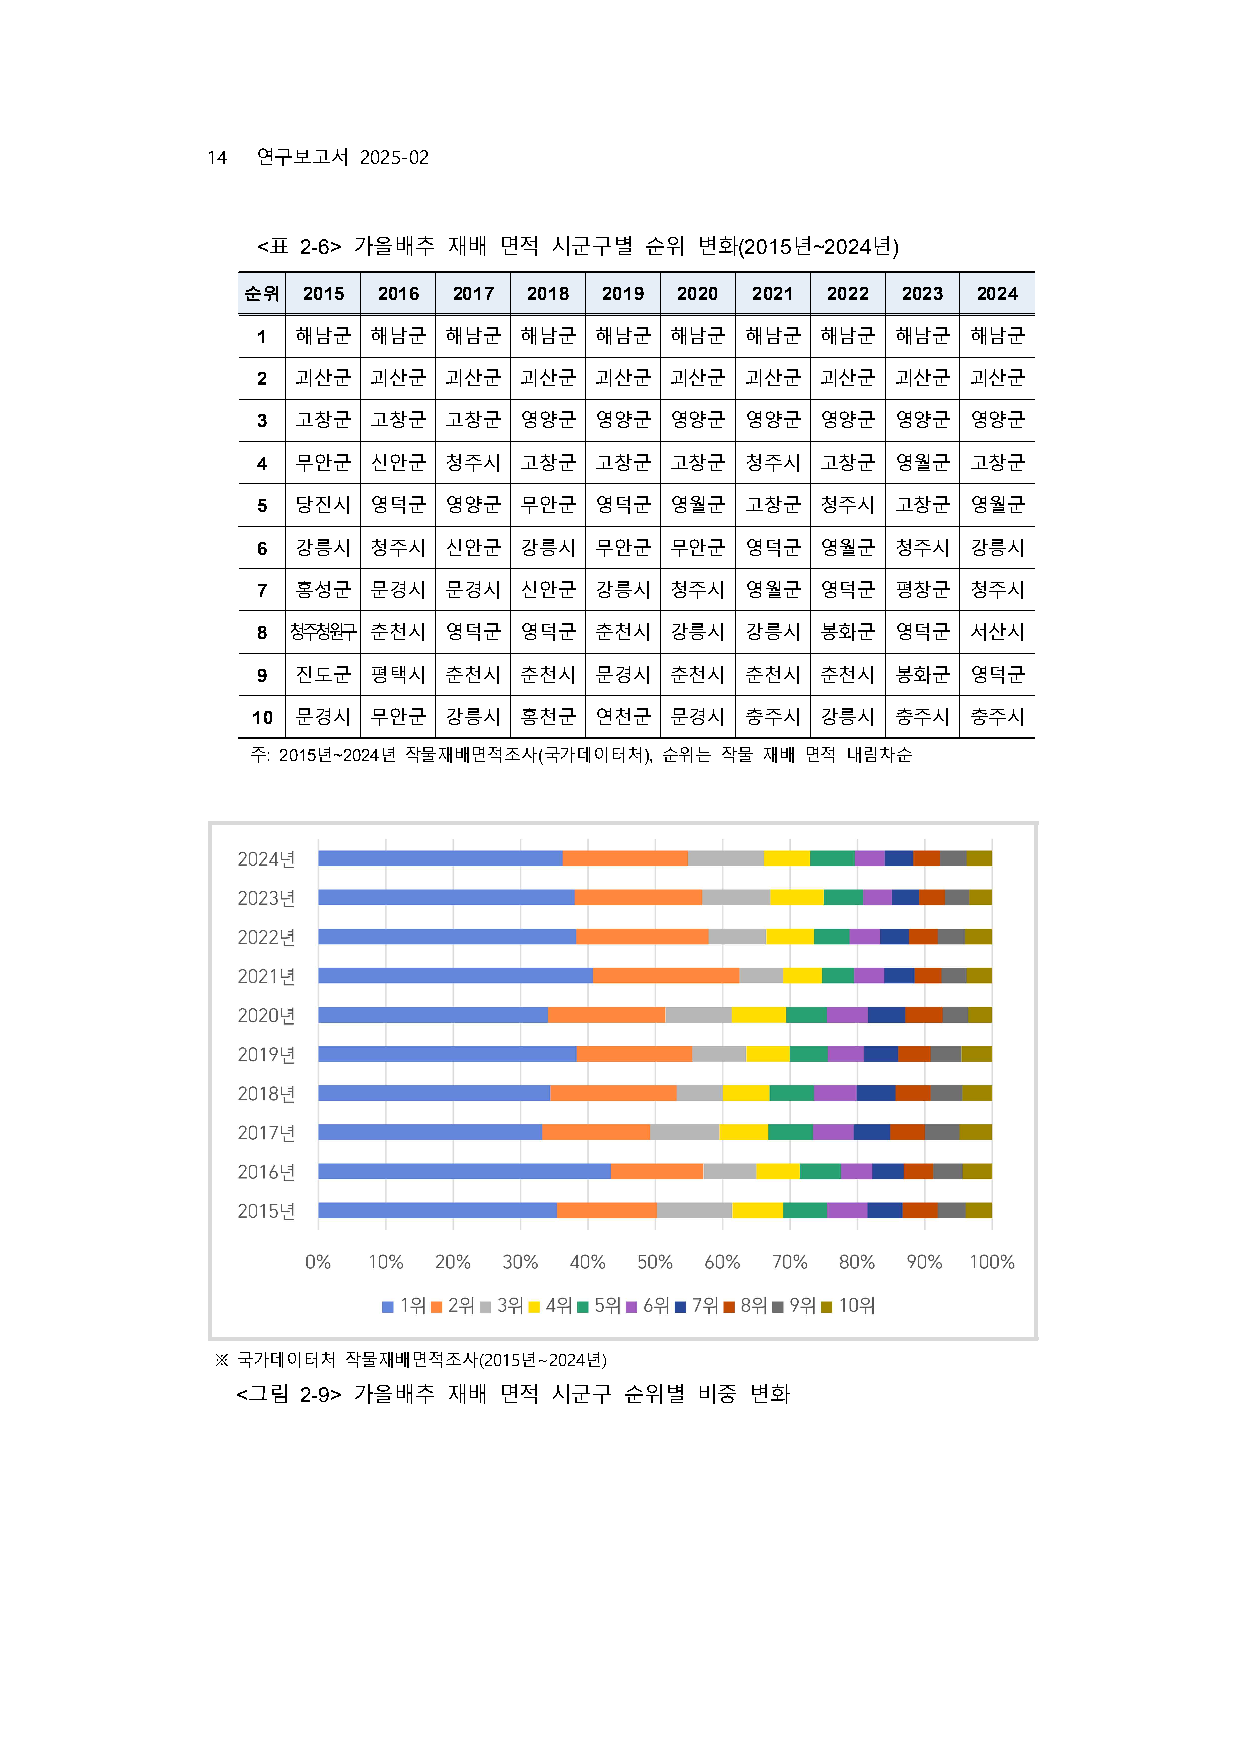

In [55]:
c_page = pdf.pages[19]
c_page.show()

In [56]:
c_page.find_all('text').inspect(limit=250)

text,x0,top,x1,bottom,font_family,font_variant,size,styles,source,confidence,color
14 연구보고서 2025-02,99,71,206,80,MalgunGothic,INPILL,9,,native,1.00,#000000
표,129,114,143,124,MalgunGothic,INPILL,10,,native,1.00,#000000
가을배추 재배 면적 시군구별 순위 변화,169,114,354,124,MalgunGothic,INPILL,10,,native,1.00,#000000
년,380,114,390,124,MalgunGothic,INPILL,10,,native,1.00,#000000
년,418,114,428,124,MalgunGothic,INPILL,10,,native,1.00,#000000
,113,114,121,124,Arial,INPILL,10,,native,1.00,#000000
<,123,114,129,124,Arial,INPILL,10,,native,1.00,#000000
2-6>,144,114,167,124,Arial,INPILL,10,,native,1.00,#000000
(2015,354,114,380,124,Arial,INPILL,10,,native,1.00,#000000
~2024,390,114,418,124,Arial,INPILL,10,,native,1.00,#000000


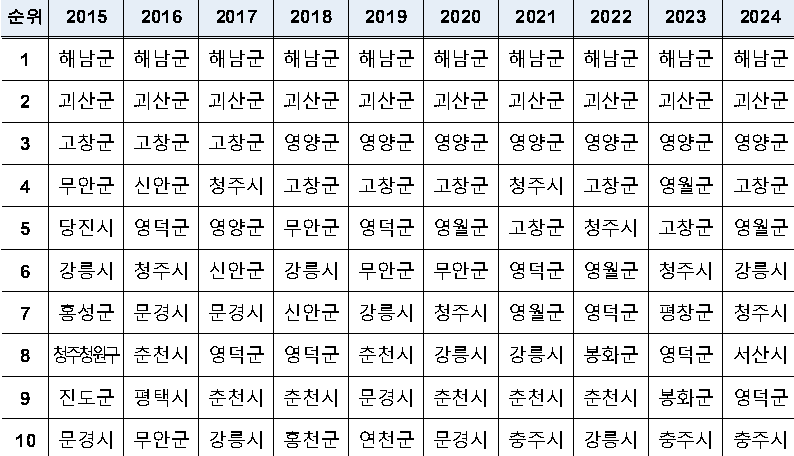

In [57]:
c_table_region = c_page.create_region(
    x0 = 114,
    top = 133,
    x1 = 495,
    bottom = 352
)

c_table_region.show(crop=True)

In [58]:
c_text = c_table_region.extract_text()

c_text

'순위 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024\n1 해남군 해남군 해남군 해남군 해남군 해남군 해남군 해남군 해남군 해남군\n2 괴산군 괴산군 괴산군 괴산군 괴산군 괴산군 괴산군 괴산군 괴산군 괴산군\n3 고창군 고창군 고창군 영양군 영양군 영양군 영양군 영양군 영양군 영양군\n4 무안군 신안군 청주시 고창군 고창군 고창군 청주시 고창군 영월군 고창군\n5 당진시 영덕군 영양군 무안군 영덕군 영월군 고창군 청주시 고창군 영월군\n6 강릉시 청주시 신안군 강릉시 무안군 무안군 영덕군 영월군 청주시 강릉시\n7 홍성군 문경시 문경시 신안군 강릉시 청주시 영월군 영덕군 평창군 청주시\n8 청주청원구 춘천시 영덕군 영덕군 춘천시 강릉시 강릉시 봉화군 영덕군 서산시\n9 진도군 평택시 춘천시 춘천시 문경시 춘천시 춘천시 춘천시 봉화군 영덕군\n10 문경시 무안군 강릉시 홍천군 연천군 문경시 충주시 강릉시 충주시 충주시'

In [59]:
c_lines = c_text.strip().split('\n')
c_lines

['순위 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024',
 '1 해남군 해남군 해남군 해남군 해남군 해남군 해남군 해남군 해남군 해남군',
 '2 괴산군 괴산군 괴산군 괴산군 괴산군 괴산군 괴산군 괴산군 괴산군 괴산군',
 '3 고창군 고창군 고창군 영양군 영양군 영양군 영양군 영양군 영양군 영양군',
 '4 무안군 신안군 청주시 고창군 고창군 고창군 청주시 고창군 영월군 고창군',
 '5 당진시 영덕군 영양군 무안군 영덕군 영월군 고창군 청주시 고창군 영월군',
 '6 강릉시 청주시 신안군 강릉시 무안군 무안군 영덕군 영월군 청주시 강릉시',
 '7 홍성군 문경시 문경시 신안군 강릉시 청주시 영월군 영덕군 평창군 청주시',
 '8 청주청원구 춘천시 영덕군 영덕군 춘천시 강릉시 강릉시 봉화군 영덕군 서산시',
 '9 진도군 평택시 춘천시 춘천시 문경시 춘천시 춘천시 춘천시 봉화군 영덕군',
 '10 문경시 무안군 강릉시 홍천군 연천군 문경시 충주시 강릉시 충주시 충주시']

In [60]:
c_header = c_lines[0].split()
c_header

['순위',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024']

In [61]:
c_rows = [c_line.split() for c_line in c_lines[1:]]
c_rows

[['1', '해남군', '해남군', '해남군', '해남군', '해남군', '해남군', '해남군', '해남군', '해남군', '해남군'],
 ['2', '괴산군', '괴산군', '괴산군', '괴산군', '괴산군', '괴산군', '괴산군', '괴산군', '괴산군', '괴산군'],
 ['3', '고창군', '고창군', '고창군', '영양군', '영양군', '영양군', '영양군', '영양군', '영양군', '영양군'],
 ['4', '무안군', '신안군', '청주시', '고창군', '고창군', '고창군', '청주시', '고창군', '영월군', '고창군'],
 ['5', '당진시', '영덕군', '영양군', '무안군', '영덕군', '영월군', '고창군', '청주시', '고창군', '영월군'],
 ['6', '강릉시', '청주시', '신안군', '강릉시', '무안군', '무안군', '영덕군', '영월군', '청주시', '강릉시'],
 ['7', '홍성군', '문경시', '문경시', '신안군', '강릉시', '청주시', '영월군', '영덕군', '평창군', '청주시'],
 ['8', '청주청원구', '춘천시', '영덕군', '영덕군', '춘천시', '강릉시', '강릉시', '봉화군', '영덕군', '서산시'],
 ['9', '진도군', '평택시', '춘천시', '춘천시', '문경시', '춘천시', '춘천시', '춘천시', '봉화군', '영덕군'],
 ['10', '문경시', '무안군', '강릉시', '홍천군', '연천군', '문경시', '충주시', '강릉시', '충주시', '충주시']]

In [62]:
eng_c_rows = [
    [c_row[0]]+ [korean_province.get(place, place) for place in c_row[1:]]
    for c_row in c_rows
]

eng_c_rows

[['1',
  'Haenam-gun',
  'Haenam-gun',
  'Haenam-gun',
  'Haenam-gun',
  'Haenam-gun',
  'Haenam-gun',
  'Haenam-gun',
  'Haenam-gun',
  'Haenam-gun',
  'Haenam-gun'],
 ['2',
  'Goesan-gun',
  'Goesan-gun',
  'Goesan-gun',
  'Goesan-gun',
  'Goesan-gun',
  'Goesan-gun',
  'Goesan-gun',
  'Goesan-gun',
  'Goesan-gun',
  'Goesan-gun'],
 ['3',
  'Gochang-gun',
  'Gochang-gun',
  'Gochang-gun',
  'Yeongyang-gun',
  'Yeongyang-gun',
  'Yeongyang-gun',
  'Yeongyang-gun',
  'Yeongyang-gun',
  'Yeongyang-gun',
  'Yeongyang-gun'],
 ['4',
  'Muan-gun',
  'Sinan-gun',
  'Cheongju-si',
  'Gochang-gun',
  'Gochang-gun',
  'Gochang-gun',
  'Cheongju-si',
  'Gochang-gun',
  'Yeongwol-gun',
  'Gochang-gun'],
 ['5',
  'Dangjin-si',
  'Yeongdeok-gun',
  'Yeongyang-gun',
  'Muan-gun',
  'Yeongdeok-gun',
  'Yeongwol-gun',
  'Gochang-gun',
  'Cheongju-si',
  'Gochang-gun',
  'Yeongwol-gun'],
 ['6',
  'Gangneung-si',
  'Cheongju-si',
  'Sinan-gun',
  'Gangneung-si',
  'Muan-gun',
  'Muan-gun',
  'Yeongdeok-

In [64]:
c_df = pd.DataFrame(eng_c_rows, columns=c_header)
c_df.head(10)

,순위,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun
1,2,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun
2,3,Gochang-gun,Gochang-gun,Gochang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun
3,4,Muan-gun,Sinan-gun,Cheongju-si,Gochang-gun,Gochang-gun,Gochang-gun,Cheongju-si,Gochang-gun,Yeongwol-gun,Gochang-gun
4,5,Dangjin-si,Yeongdeok-gun,Yeongyang-gun,Muan-gun,Yeongdeok-gun,Yeongwol-gun,Gochang-gun,Cheongju-si,Gochang-gun,Yeongwol-gun
5,6,Gangneung-si,Cheongju-si,Sinan-gun,Gangneung-si,Muan-gun,Muan-gun,Yeongdeok-gun,Yeongwol-gun,Cheongju-si,Gangneung-si
6,7,Hongseong-gun,Mungyeong-si,Mungyeong-si,Sinan-gun,Gangneung-si,Cheongju-si,Yeongwol-gun,Yeongdeok-gun,Pyeongchang-gun,Cheongju-si
7,8,청주청원구,Chuncheon-si,Yeongdeok-gun,Yeongdeok-gun,Chuncheon-si,Gangneung-si,Gangneung-si,Bonghwa-gun,Yeongdeok-gun,Seosan-si
8,9,Jindo-gun,Pyeongtaek-si,Chuncheon-si,Chuncheon-si,Mungyeong-si,Chuncheon-si,Chuncheon-si,Chuncheon-si,Bonghwa-gun,Yeongdeok-gun
9,10,Mungyeong-si,Muan-gun,Gangneung-si,Hongcheon-gun,Yeoncheon-gun,Mungyeong-si,Chungju-si,Gangneung-si,Chungju-si,Chungju-si


In [65]:
# change 청주청원구 to Cheongju-si

c_df.loc[c_df["2015"] == "청주청원구", "2015"] = "Cheongju-si"
c_df

,순위,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun
1,2,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun
2,3,Gochang-gun,Gochang-gun,Gochang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun
3,4,Muan-gun,Sinan-gun,Cheongju-si,Gochang-gun,Gochang-gun,Gochang-gun,Cheongju-si,Gochang-gun,Yeongwol-gun,Gochang-gun
4,5,Dangjin-si,Yeongdeok-gun,Yeongyang-gun,Muan-gun,Yeongdeok-gun,Yeongwol-gun,Gochang-gun,Cheongju-si,Gochang-gun,Yeongwol-gun
5,6,Gangneung-si,Cheongju-si,Sinan-gun,Gangneung-si,Muan-gun,Muan-gun,Yeongdeok-gun,Yeongwol-gun,Cheongju-si,Gangneung-si
6,7,Hongseong-gun,Mungyeong-si,Mungyeong-si,Sinan-gun,Gangneung-si,Cheongju-si,Yeongwol-gun,Yeongdeok-gun,Pyeongchang-gun,Cheongju-si
7,8,Cheongju-si,Chuncheon-si,Yeongdeok-gun,Yeongdeok-gun,Chuncheon-si,Gangneung-si,Gangneung-si,Bonghwa-gun,Yeongdeok-gun,Seosan-si
8,9,Jindo-gun,Pyeongtaek-si,Chuncheon-si,Chuncheon-si,Mungyeong-si,Chuncheon-si,Chuncheon-si,Chuncheon-si,Bonghwa-gun,Yeongdeok-gun
9,10,Mungyeong-si,Muan-gun,Gangneung-si,Hongcheon-gun,Yeoncheon-gun,Mungyeong-si,Chungju-si,Gangneung-si,Chungju-si,Chungju-si


In [88]:
c_df = c_df.drop(columns='순위')
c_df['score'] = [10,9,8,7,6,5,4,3,2,1]
c_df.to_csv("cabbage.csv", index=False)

c_df

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,score
0,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,10
1,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,Goesan-gun,9
2,Gochang-gun,Gochang-gun,Gochang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,8
3,Muan-gun,Sinan-gun,Cheongju-si,Gochang-gun,Gochang-gun,Gochang-gun,Cheongju-si,Gochang-gun,Yeongwol-gun,Gochang-gun,7
4,Dangjin-si,Yeongdeok-gun,Yeongyang-gun,Muan-gun,Yeongdeok-gun,Yeongwol-gun,Gochang-gun,Cheongju-si,Gochang-gun,Yeongwol-gun,6
5,Gangneung-si,Cheongju-si,Sinan-gun,Gangneung-si,Muan-gun,Muan-gun,Yeongdeok-gun,Yeongwol-gun,Cheongju-si,Gangneung-si,5
6,Hongseong-gun,Mungyeong-si,Mungyeong-si,Sinan-gun,Gangneung-si,Cheongju-si,Yeongwol-gun,Yeongdeok-gun,Pyeongchang-gun,Cheongju-si,4
7,Cheongju-si,Chuncheon-si,Yeongdeok-gun,Yeongdeok-gun,Chuncheon-si,Gangneung-si,Gangneung-si,Bonghwa-gun,Yeongdeok-gun,Seosan-si,3
8,Jindo-gun,Pyeongtaek-si,Chuncheon-si,Chuncheon-si,Mungyeong-si,Chuncheon-si,Chuncheon-si,Chuncheon-si,Bonghwa-gun,Yeongdeok-gun,2
9,Mungyeong-si,Muan-gun,Gangneung-si,Hongcheon-gun,Yeoncheon-gun,Mungyeong-si,Chungju-si,Gangneung-si,Chungju-si,Chungju-si,1


### 4. Autumn radish

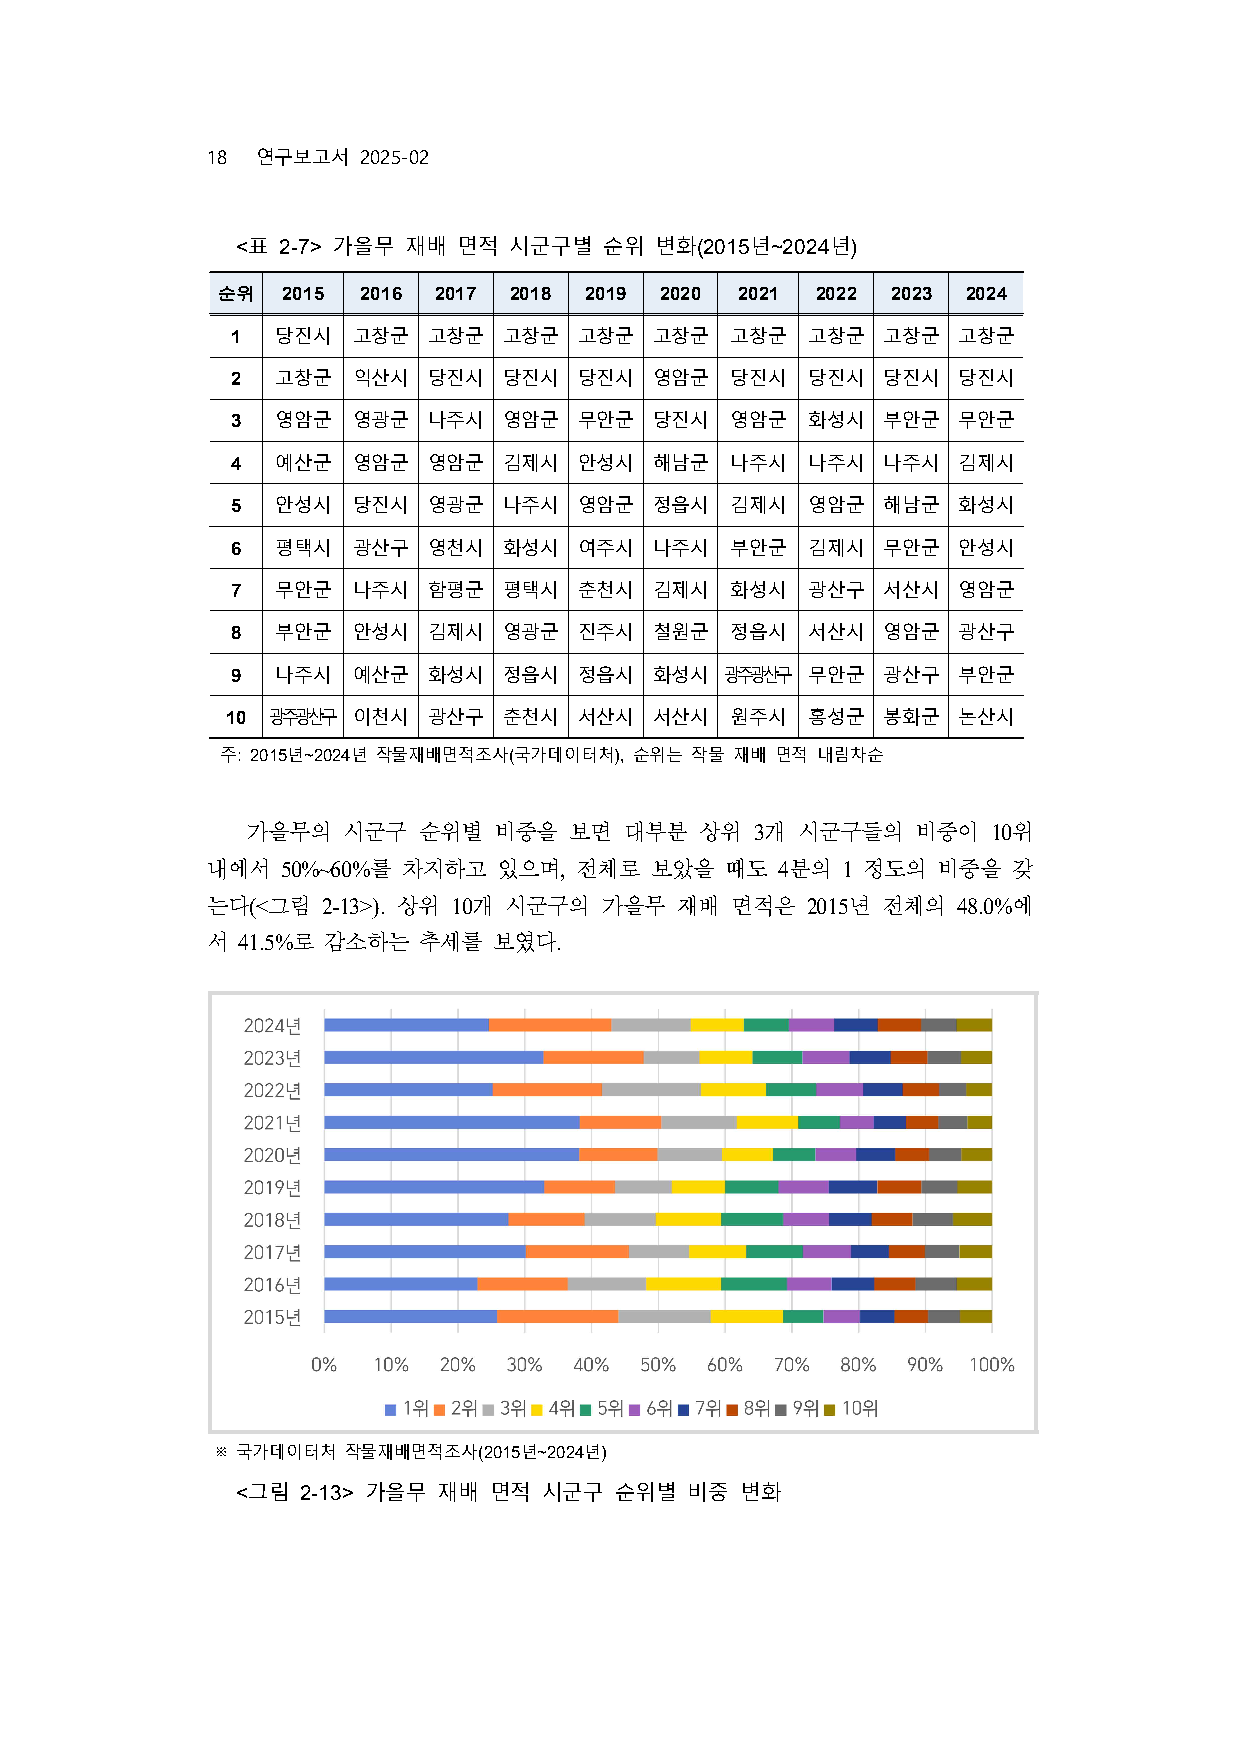

In [67]:
r_page = pdf.pages[23]
r_page.show()

In [68]:
r_page.find_all('text').inspect(limit=250)

text,x0,top,x1,bottom,font_family,font_variant,size,styles,source,confidence,color
18 연구보고서 2025-02,99,71,206,80,MalgunGothic,INPILL,9,,native,1.00,#000000
표,119,114,133,124,MalgunGothic,INPILL,10,,native,1.00,#000000
가을무 재배 면적 시군구별 순위 변화,159,114,334,124,MalgunGothic,INPILL,10,,native,1.00,#000000
년,360,114,370,124,MalgunGothic,INPILL,10,,native,1.00,#000000
년,398,114,408,124,MalgunGothic,INPILL,10,,native,1.00,#000000
<,113,114,119,124,Arial,INPILL,10,,native,1.00,#000000
2-7>,134,114,157,124,Arial,INPILL,10,,native,1.00,#000000
(2015,334,114,360,124,Arial,INPILL,10,,native,1.00,#000000
~2024,370,114,398,124,Arial,INPILL,10,,native,1.00,#000000
),408,114,411,124,Arial,INPILL,10,,native,1.00,#000000


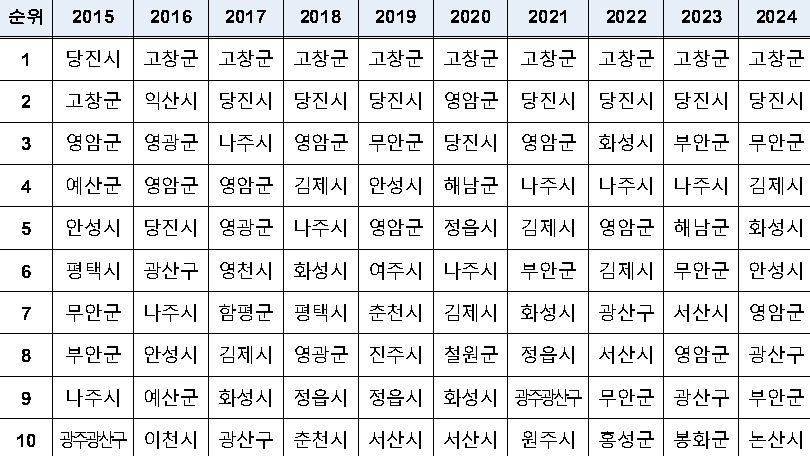

In [69]:
r_table_region = r_page.create_region(
    x0 = 101,
    top = 133,
    x1 = 490,
    bottom = 352
)

r_table_region.show(crop=True)

In [70]:
r_text = r_table_region.extract_text()
r_text

'순위 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024\n1 당진시 고창군 고창군 고창군 고창군 고창군 고창군 고창군 고창군 고창군\n2 고창군 익산시 당진시 당진시 당진시 영암군 당진시 당진시 당진시 당진시\n3 영암군 영광군 나주시 영암군 무안군 당진시 영암군 화성시 부안군 무안군\n4 예산군 영암군 영암군 김제시 안성시 해남군 나주시 나주시 나주시 김제시\n5 안성시 당진시 영광군 나주시 영암군 정읍시 김제시 영암군 해남군 화성시\n6 평택시 광산구 영천시 화성시 여주시 나주시 부안군 김제시 무안군 안성시\n7 무안군 나주시 함평군 평택시 춘천시 김제시 화성시 광산구 서산시 영암군\n8 부안군 안성시 김제시 영광군 진주시 철원군 정읍시 서산시 영암군 광산구\n9 나주시 예산군 화성시 정읍시 정읍시 화성시 광주광산구 무안군 광산구 부안군\n10 광주광산구 이천시 광산구 춘천시 서산시 서산시 원주시 홍성군 봉화군 논산시'

In [71]:
r_lines = r_text.strip().split('\n')
r_lines

['순위 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024',
 '1 당진시 고창군 고창군 고창군 고창군 고창군 고창군 고창군 고창군 고창군',
 '2 고창군 익산시 당진시 당진시 당진시 영암군 당진시 당진시 당진시 당진시',
 '3 영암군 영광군 나주시 영암군 무안군 당진시 영암군 화성시 부안군 무안군',
 '4 예산군 영암군 영암군 김제시 안성시 해남군 나주시 나주시 나주시 김제시',
 '5 안성시 당진시 영광군 나주시 영암군 정읍시 김제시 영암군 해남군 화성시',
 '6 평택시 광산구 영천시 화성시 여주시 나주시 부안군 김제시 무안군 안성시',
 '7 무안군 나주시 함평군 평택시 춘천시 김제시 화성시 광산구 서산시 영암군',
 '8 부안군 안성시 김제시 영광군 진주시 철원군 정읍시 서산시 영암군 광산구',
 '9 나주시 예산군 화성시 정읍시 정읍시 화성시 광주광산구 무안군 광산구 부안군',
 '10 광주광산구 이천시 광산구 춘천시 서산시 서산시 원주시 홍성군 봉화군 논산시']

In [72]:
r_header = r_lines[0].split()
r_header

['순위',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024']

In [89]:
r_rows = [r_line.split() for r_line in r_lines[1:]]
r_rows

[['1', '당진시', '고창군', '고창군', '고창군', '고창군', '고창군', '고창군', '고창군', '고창군', '고창군'],
 ['2', '고창군', '익산시', '당진시', '당진시', '당진시', '영암군', '당진시', '당진시', '당진시', '당진시'],
 ['3', '영암군', '영광군', '나주시', '영암군', '무안군', '당진시', '영암군', '화성시', '부안군', '무안군'],
 ['4', '예산군', '영암군', '영암군', '김제시', '안성시', '해남군', '나주시', '나주시', '나주시', '김제시'],
 ['5', '안성시', '당진시', '영광군', '나주시', '영암군', '정읍시', '김제시', '영암군', '해남군', '화성시'],
 ['6', '평택시', '광산구', '영천시', '화성시', '여주시', '나주시', '부안군', '김제시', '무안군', '안성시'],
 ['7', '무안군', '나주시', '함평군', '평택시', '춘천시', '김제시', '화성시', '광산구', '서산시', '영암군'],
 ['8', '부안군', '안성시', '김제시', '영광군', '진주시', '철원군', '정읍시', '서산시', '영암군', '광산구'],
 ['9', '나주시', '예산군', '화성시', '정읍시', '정읍시', '화성시', '광주광산구', '무안군', '광산구', '부안군'],
 ['10',
  '광주광산구',
  '이천시',
  '광산구',
  '춘천시',
  '서산시',
  '서산시',
  '원주시',
  '홍성군',
  '봉화군',
  '논산시']]

In [90]:
eng_r_rows = [
    [korean_province.get(place, place) for place in r_row[1:]]
    for r_row in r_rows
]

eng_r_rows

[['Dangjin-si',
  'Gochang-gun',
  'Gochang-gun',
  'Gochang-gun',
  'Gochang-gun',
  'Gochang-gun',
  'Gochang-gun',
  'Gochang-gun',
  'Gochang-gun',
  'Gochang-gun'],
 ['Gochang-gun',
  'Iksan-si',
  'Dangjin-si',
  'Dangjin-si',
  'Dangjin-si',
  'Yeongam-gun',
  'Dangjin-si',
  'Dangjin-si',
  'Dangjin-si',
  'Dangjin-si'],
 ['Yeongam-gun',
  'Yeonggwang-gun',
  'Naju-si',
  'Yeongam-gun',
  'Muan-gun',
  'Dangjin-si',
  'Yeongam-gun',
  'Hwaseong-si',
  'Buan-gun',
  'Muan-gun'],
 ['Yesan-gun',
  'Yeongam-gun',
  'Yeongam-gun',
  'Gimje-si',
  'Anseong-si',
  'Haenam-gun',
  'Naju-si',
  'Naju-si',
  'Naju-si',
  'Gimje-si'],
 ['Anseong-si',
  'Dangjin-si',
  'Yeonggwang-gun',
  'Naju-si',
  'Yeongam-gun',
  'Jeongeup-si',
  'Gimje-si',
  'Yeongam-gun',
  'Haenam-gun',
  'Hwaseong-si'],
 ['Pyeongtaek-si',
  'Gwangsan-gu',
  'Yeongcheon-si',
  'Hwaseong-si',
  'Yeoju-si',
  'Naju-si',
  'Buan-gun',
  'Gimje-si',
  'Muan-gun',
  'Anseong-si'],
 ['Muan-gun',
  'Naju-si',
  'Hampyeon

In [92]:
r_df = pd.DataFrame(eng_r_rows, columns=r_header[1:])
r_df.head(10)

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Dangjin-si,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun
1,Gochang-gun,Iksan-si,Dangjin-si,Dangjin-si,Dangjin-si,Yeongam-gun,Dangjin-si,Dangjin-si,Dangjin-si,Dangjin-si
2,Yeongam-gun,Yeonggwang-gun,Naju-si,Yeongam-gun,Muan-gun,Dangjin-si,Yeongam-gun,Hwaseong-si,Buan-gun,Muan-gun
3,Yesan-gun,Yeongam-gun,Yeongam-gun,Gimje-si,Anseong-si,Haenam-gun,Naju-si,Naju-si,Naju-si,Gimje-si
4,Anseong-si,Dangjin-si,Yeonggwang-gun,Naju-si,Yeongam-gun,Jeongeup-si,Gimje-si,Yeongam-gun,Haenam-gun,Hwaseong-si
5,Pyeongtaek-si,Gwangsan-gu,Yeongcheon-si,Hwaseong-si,Yeoju-si,Naju-si,Buan-gun,Gimje-si,Muan-gun,Anseong-si
6,Muan-gun,Naju-si,Hampyeong-gun,Pyeongtaek-si,Chuncheon-si,Gimje-si,Hwaseong-si,Gwangsan-gu,Seosan-si,Yeongam-gun
7,Buan-gun,Anseong-si,Gimje-si,Yeonggwang-gun,Jinju-si,Cheorwon-gun,Jeongeup-si,Seosan-si,Yeongam-gun,Gwangsan-gu
8,Naju-si,Yesan-gun,Hwaseong-si,Jeongeup-si,Jeongeup-si,Hwaseong-si,광주광산구,Muan-gun,Gwangsan-gu,Buan-gun
9,광주광산구,Icheon-si,Gwangsan-gu,Chuncheon-si,Seosan-si,Seosan-si,Wonju-si,Hongseong-gun,Bonghwa-gun,Nonsan-si


In [93]:
r_df.loc[r_df['2015'] == '광주광산구', '2015'] = 'Gwangsan-gu'
r_df.loc[r_df['2021'] == '광주광산구', '2021'] = 'Gwangsan-gu'

r_df.head(10)

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Dangjin-si,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun
1,Gochang-gun,Iksan-si,Dangjin-si,Dangjin-si,Dangjin-si,Yeongam-gun,Dangjin-si,Dangjin-si,Dangjin-si,Dangjin-si
2,Yeongam-gun,Yeonggwang-gun,Naju-si,Yeongam-gun,Muan-gun,Dangjin-si,Yeongam-gun,Hwaseong-si,Buan-gun,Muan-gun
3,Yesan-gun,Yeongam-gun,Yeongam-gun,Gimje-si,Anseong-si,Haenam-gun,Naju-si,Naju-si,Naju-si,Gimje-si
4,Anseong-si,Dangjin-si,Yeonggwang-gun,Naju-si,Yeongam-gun,Jeongeup-si,Gimje-si,Yeongam-gun,Haenam-gun,Hwaseong-si
5,Pyeongtaek-si,Gwangsan-gu,Yeongcheon-si,Hwaseong-si,Yeoju-si,Naju-si,Buan-gun,Gimje-si,Muan-gun,Anseong-si
6,Muan-gun,Naju-si,Hampyeong-gun,Pyeongtaek-si,Chuncheon-si,Gimje-si,Hwaseong-si,Gwangsan-gu,Seosan-si,Yeongam-gun
7,Buan-gun,Anseong-si,Gimje-si,Yeonggwang-gun,Jinju-si,Cheorwon-gun,Jeongeup-si,Seosan-si,Yeongam-gun,Gwangsan-gu
8,Naju-si,Yesan-gun,Hwaseong-si,Jeongeup-si,Jeongeup-si,Hwaseong-si,Gwangsan-gu,Muan-gun,Gwangsan-gu,Buan-gun
9,Gwangsan-gu,Icheon-si,Gwangsan-gu,Chuncheon-si,Seosan-si,Seosan-si,Wonju-si,Hongseong-gun,Bonghwa-gun,Nonsan-si


In [94]:
r_df['score'] = [10,9,8,7,6,5,4,3,2,1]
r_df.to_csv("radish.csv", index=False)

r_df

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,score
0,Dangjin-si,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,Gochang-gun,10
1,Gochang-gun,Iksan-si,Dangjin-si,Dangjin-si,Dangjin-si,Yeongam-gun,Dangjin-si,Dangjin-si,Dangjin-si,Dangjin-si,9
2,Yeongam-gun,Yeonggwang-gun,Naju-si,Yeongam-gun,Muan-gun,Dangjin-si,Yeongam-gun,Hwaseong-si,Buan-gun,Muan-gun,8
3,Yesan-gun,Yeongam-gun,Yeongam-gun,Gimje-si,Anseong-si,Haenam-gun,Naju-si,Naju-si,Naju-si,Gimje-si,7
4,Anseong-si,Dangjin-si,Yeonggwang-gun,Naju-si,Yeongam-gun,Jeongeup-si,Gimje-si,Yeongam-gun,Haenam-gun,Hwaseong-si,6
5,Pyeongtaek-si,Gwangsan-gu,Yeongcheon-si,Hwaseong-si,Yeoju-si,Naju-si,Buan-gun,Gimje-si,Muan-gun,Anseong-si,5
6,Muan-gun,Naju-si,Hampyeong-gun,Pyeongtaek-si,Chuncheon-si,Gimje-si,Hwaseong-si,Gwangsan-gu,Seosan-si,Yeongam-gun,4
7,Buan-gun,Anseong-si,Gimje-si,Yeonggwang-gun,Jinju-si,Cheorwon-gun,Jeongeup-si,Seosan-si,Yeongam-gun,Gwangsan-gu,3
8,Naju-si,Yesan-gun,Hwaseong-si,Jeongeup-si,Jeongeup-si,Hwaseong-si,Gwangsan-gu,Muan-gun,Gwangsan-gu,Buan-gun,2
9,Gwangsan-gu,Icheon-si,Gwangsan-gu,Chuncheon-si,Seosan-si,Seosan-si,Wonju-si,Hongseong-gun,Bonghwa-gun,Nonsan-si,1


### 5. Pepper

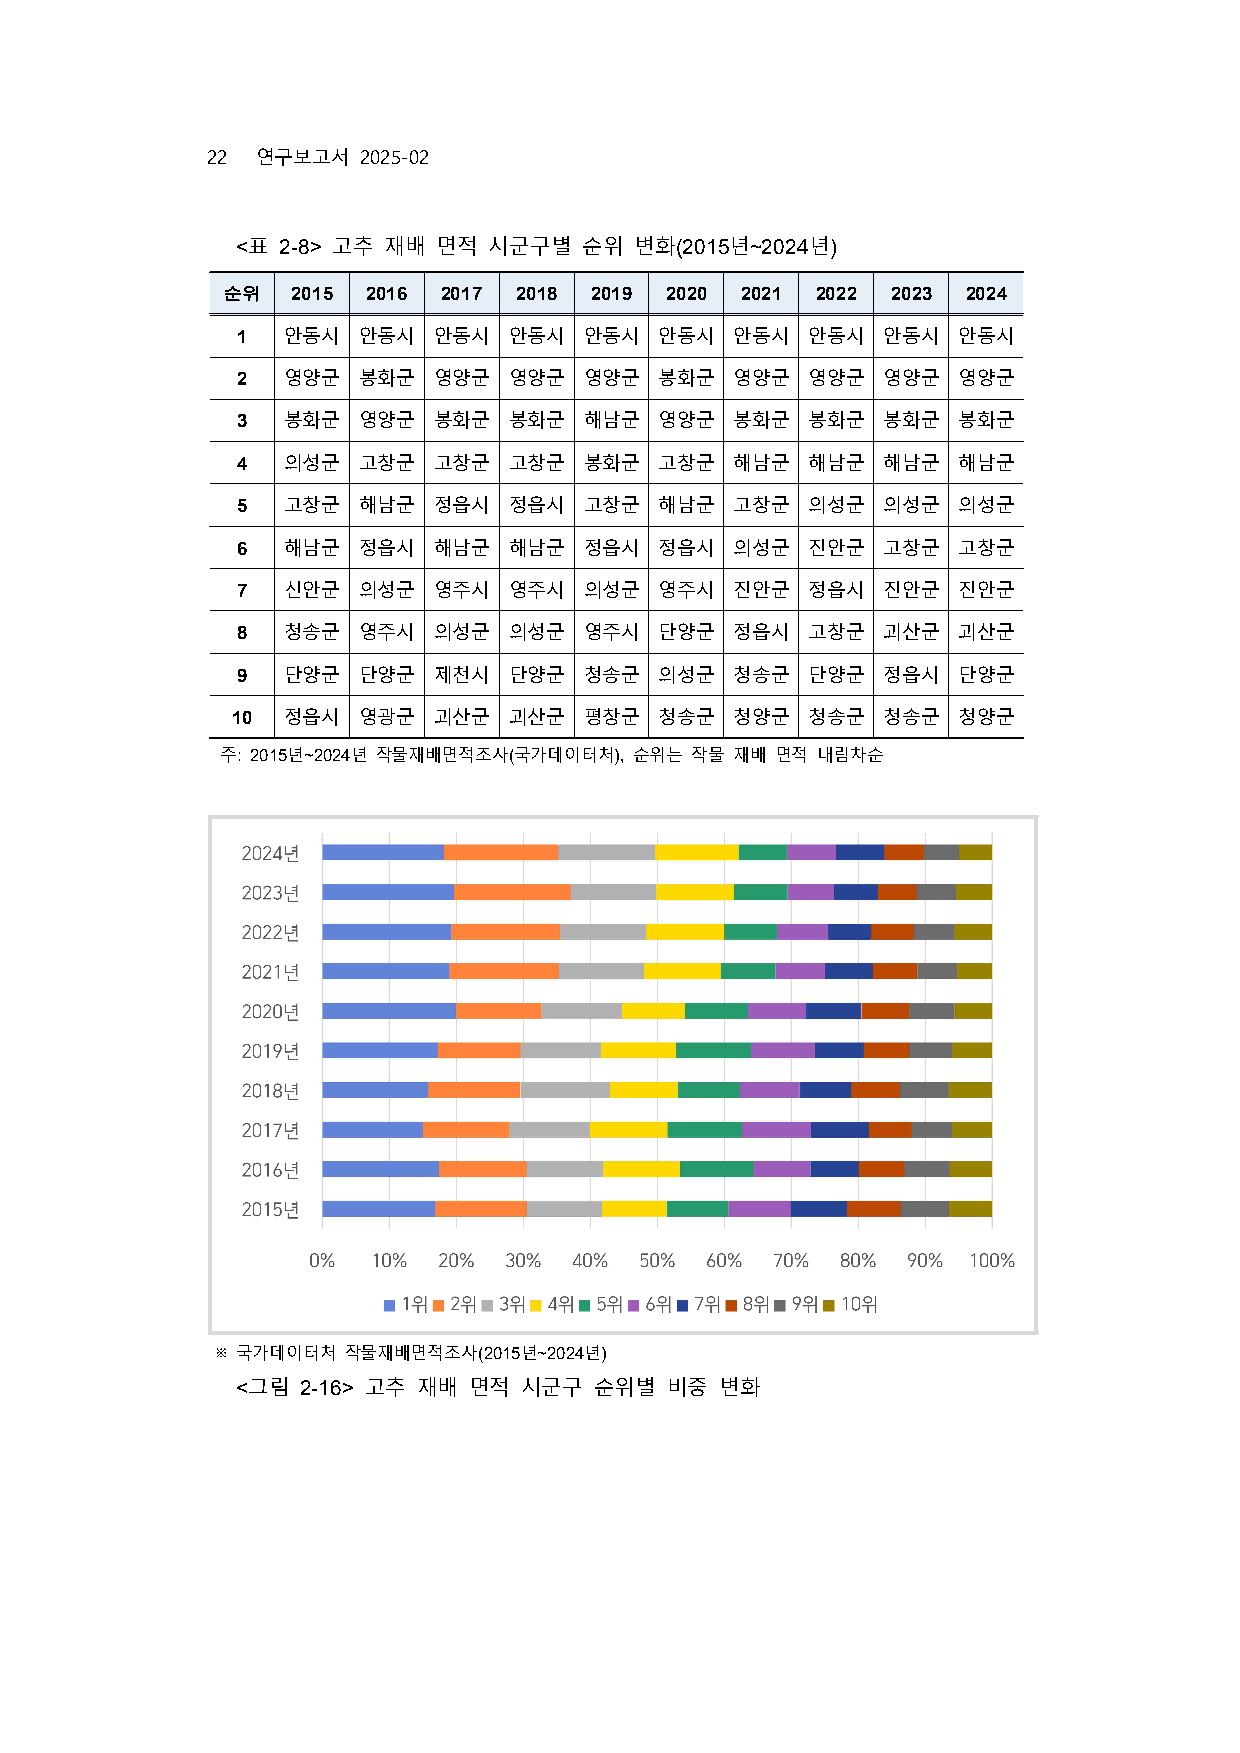

In [95]:
p_page = pdf.pages[27]
p_page.show()

In [96]:
p_page.find_all('text').inspect(limit=250)

text,x0,top,x1,bottom,font_family,font_variant,size,styles,source,confidence,color
22 연구보고서 2025-02,99,71,206,80,MalgunGothic,INPILL,9,,native,1.00,#000000
표,119,114,133,124,MalgunGothic,INPILL,10,,native,1.00,#000000
고추 재배 면적 시군구별 순위 변화,159,114,324,124,MalgunGothic,INPILL,10,,native,1.00,#000000
년,350,114,360,124,MalgunGothic,INPILL,10,,native,1.00,#000000
년,388,114,398,124,MalgunGothic,INPILL,10,,native,1.00,#000000
<,113,114,119,124,Arial,INPILL,10,,native,1.00,#000000
2-8>,134,114,157,124,Arial,INPILL,10,,native,1.00,#000000
(2015,324,114,350,124,Arial,INPILL,10,,native,1.00,#000000
~2024,360,114,388,124,Arial,INPILL,10,,native,1.00,#000000
),398,114,401,124,Arial,INPILL,10,,native,1.00,#000000


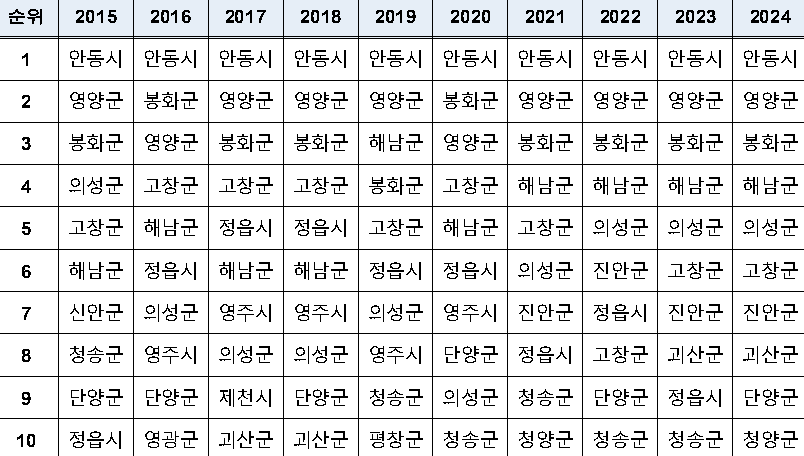

In [97]:
p_table_region = p_page.create_region(
    x0 = 104,
    top = 133,
    x1= 490,
    bottom = 352
)

p_table_region.show(crop=True)

In [98]:
p_text = p_table_region.extract_text()
p_text

'순위 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024\n1 안동시 안동시 안동시 안동시 안동시 안동시 안동시 안동시 안동시 안동시\n2 영양군 봉화군 영양군 영양군 영양군 봉화군 영양군 영양군 영양군 영양군\n3 봉화군 영양군 봉화군 봉화군 해남군 영양군 봉화군 봉화군 봉화군 봉화군\n4 의성군 고창군 고창군 고창군 봉화군 고창군 해남군 해남군 해남군 해남군\n5 고창군 해남군 정읍시 정읍시 고창군 해남군 고창군 의성군 의성군 의성군\n6 해남군 정읍시 해남군 해남군 정읍시 정읍시 의성군 진안군 고창군 고창군\n7 신안군 의성군 영주시 영주시 의성군 영주시 진안군 정읍시 진안군 진안군\n8 청송군 영주시 의성군 의성군 영주시 단양군 정읍시 고창군 괴산군 괴산군\n9 단양군 단양군 제천시 단양군 청송군 의성군 청송군 단양군 정읍시 단양군\n10 정읍시 영광군 괴산군 괴산군 평창군 청송군 청양군 청송군 청송군 청양군'

In [99]:
p_lines = p_text.strip().split('\n')
p_lines

['순위 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024',
 '1 안동시 안동시 안동시 안동시 안동시 안동시 안동시 안동시 안동시 안동시',
 '2 영양군 봉화군 영양군 영양군 영양군 봉화군 영양군 영양군 영양군 영양군',
 '3 봉화군 영양군 봉화군 봉화군 해남군 영양군 봉화군 봉화군 봉화군 봉화군',
 '4 의성군 고창군 고창군 고창군 봉화군 고창군 해남군 해남군 해남군 해남군',
 '5 고창군 해남군 정읍시 정읍시 고창군 해남군 고창군 의성군 의성군 의성군',
 '6 해남군 정읍시 해남군 해남군 정읍시 정읍시 의성군 진안군 고창군 고창군',
 '7 신안군 의성군 영주시 영주시 의성군 영주시 진안군 정읍시 진안군 진안군',
 '8 청송군 영주시 의성군 의성군 영주시 단양군 정읍시 고창군 괴산군 괴산군',
 '9 단양군 단양군 제천시 단양군 청송군 의성군 청송군 단양군 정읍시 단양군',
 '10 정읍시 영광군 괴산군 괴산군 평창군 청송군 청양군 청송군 청송군 청양군']

In [100]:
p_header = p_lines[0].split()
p_header

['순위',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024']

In [101]:
p_rows = [p_line.split() for p_line in p_lines[1:]]
p_rows

[['1', '안동시', '안동시', '안동시', '안동시', '안동시', '안동시', '안동시', '안동시', '안동시', '안동시'],
 ['2', '영양군', '봉화군', '영양군', '영양군', '영양군', '봉화군', '영양군', '영양군', '영양군', '영양군'],
 ['3', '봉화군', '영양군', '봉화군', '봉화군', '해남군', '영양군', '봉화군', '봉화군', '봉화군', '봉화군'],
 ['4', '의성군', '고창군', '고창군', '고창군', '봉화군', '고창군', '해남군', '해남군', '해남군', '해남군'],
 ['5', '고창군', '해남군', '정읍시', '정읍시', '고창군', '해남군', '고창군', '의성군', '의성군', '의성군'],
 ['6', '해남군', '정읍시', '해남군', '해남군', '정읍시', '정읍시', '의성군', '진안군', '고창군', '고창군'],
 ['7', '신안군', '의성군', '영주시', '영주시', '의성군', '영주시', '진안군', '정읍시', '진안군', '진안군'],
 ['8', '청송군', '영주시', '의성군', '의성군', '영주시', '단양군', '정읍시', '고창군', '괴산군', '괴산군'],
 ['9', '단양군', '단양군', '제천시', '단양군', '청송군', '의성군', '청송군', '단양군', '정읍시', '단양군'],
 ['10', '정읍시', '영광군', '괴산군', '괴산군', '평창군', '청송군', '청양군', '청송군', '청송군', '청양군']]

In [103]:
eng_p_rows = [
    [korean_province.get(place,place) for place in p_row[1:]]
    for p_row in p_rows
]

eng_p_rows

[['Andong-si',
  'Andong-si',
  'Andong-si',
  'Andong-si',
  'Andong-si',
  'Andong-si',
  'Andong-si',
  'Andong-si',
  'Andong-si',
  'Andong-si'],
 ['Yeongyang-gun',
  'Bonghwa-gun',
  'Yeongyang-gun',
  'Yeongyang-gun',
  'Yeongyang-gun',
  'Bonghwa-gun',
  'Yeongyang-gun',
  'Yeongyang-gun',
  'Yeongyang-gun',
  'Yeongyang-gun'],
 ['Bonghwa-gun',
  'Yeongyang-gun',
  'Bonghwa-gun',
  'Bonghwa-gun',
  'Haenam-gun',
  'Yeongyang-gun',
  'Bonghwa-gun',
  'Bonghwa-gun',
  'Bonghwa-gun',
  'Bonghwa-gun'],
 ['Uiseong-gun',
  'Gochang-gun',
  'Gochang-gun',
  'Gochang-gun',
  'Bonghwa-gun',
  'Gochang-gun',
  'Haenam-gun',
  'Haenam-gun',
  'Haenam-gun',
  'Haenam-gun'],
 ['Gochang-gun',
  'Haenam-gun',
  'Jeongeup-si',
  'Jeongeup-si',
  'Gochang-gun',
  'Haenam-gun',
  'Gochang-gun',
  'Uiseong-gun',
  'Uiseong-gun',
  'Uiseong-gun'],
 ['Haenam-gun',
  'Jeongeup-si',
  'Haenam-gun',
  'Haenam-gun',
  'Jeongeup-si',
  'Jeongeup-si',
  'Uiseong-gun',
  'Jinan-gun',
  'Gochang-gun',
  'G

In [106]:
p_df = pd.DataFrame(eng_p_rows, columns=p_header[1:])
p_df.head(10)

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si
1,Yeongyang-gun,Bonghwa-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Bonghwa-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun
2,Bonghwa-gun,Yeongyang-gun,Bonghwa-gun,Bonghwa-gun,Haenam-gun,Yeongyang-gun,Bonghwa-gun,Bonghwa-gun,Bonghwa-gun,Bonghwa-gun
3,Uiseong-gun,Gochang-gun,Gochang-gun,Gochang-gun,Bonghwa-gun,Gochang-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun
4,Gochang-gun,Haenam-gun,Jeongeup-si,Jeongeup-si,Gochang-gun,Haenam-gun,Gochang-gun,Uiseong-gun,Uiseong-gun,Uiseong-gun
5,Haenam-gun,Jeongeup-si,Haenam-gun,Haenam-gun,Jeongeup-si,Jeongeup-si,Uiseong-gun,Jinan-gun,Gochang-gun,Gochang-gun
6,Sinan-gun,Uiseong-gun,Yeongju-si,Yeongju-si,Uiseong-gun,Yeongju-si,Jinan-gun,Jeongeup-si,Jinan-gun,Jinan-gun
7,Cheongsong-gun,Yeongju-si,Uiseong-gun,Uiseong-gun,Yeongju-si,Danyang-gun,Jeongeup-si,Gochang-gun,Goesan-gun,Goesan-gun
8,Danyang-gun,Danyang-gun,Jecheon-si,Danyang-gun,Cheongsong-gun,Uiseong-gun,Cheongsong-gun,Danyang-gun,Jeongeup-si,Danyang-gun
9,Jeongeup-si,Yeonggwang-gun,Goesan-gun,Goesan-gun,Pyeongchang-gun,Cheongsong-gun,Cheongyang-gun,Cheongsong-gun,Cheongsong-gun,Cheongyang-gun


In [108]:
p_df['score'] = [10,9,8,7,6,5,4,3,2,1]
p_df.to_csv("pepper.csv", index=False)

p_df.head()

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,score
0,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,Andong-si,10
1,Yeongyang-gun,Bonghwa-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Bonghwa-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,Yeongyang-gun,9
2,Bonghwa-gun,Yeongyang-gun,Bonghwa-gun,Bonghwa-gun,Haenam-gun,Yeongyang-gun,Bonghwa-gun,Bonghwa-gun,Bonghwa-gun,Bonghwa-gun,8
3,Uiseong-gun,Gochang-gun,Gochang-gun,Gochang-gun,Bonghwa-gun,Gochang-gun,Haenam-gun,Haenam-gun,Haenam-gun,Haenam-gun,7
4,Gochang-gun,Haenam-gun,Jeongeup-si,Jeongeup-si,Gochang-gun,Haenam-gun,Gochang-gun,Uiseong-gun,Uiseong-gun,Uiseong-gun,6
